## Sección 1: Ingeniería de características

## Ingeniería de características con regresión lineal: aplicada a los datos de vivienda de Ames
Utilizando los datos de vivienda de Ames:

Dean De Cock, Universidad Estatal Truman, Revista de Educación Estadística, Volumen 19, Número 3 (2011), www.amstat.org/publications/jse/v19n3/decock.pdf

En este cuaderno, construiremos modelos de regresión lineal para predecir los precios de la vivienda a partir de estos datos. En particular, nos proponemos mejorar un conjunto de características base mediante la **ingeniería de características** : derivando nuevas características de nuestros datos existentes. La ingeniería de características suele marcar la diferencia entre un modelo débil y uno sólido.

Utilizaremos la exploración visual, la comprensión del dominio y la intuición para construir nuevas características que serán útiles más adelante en el curso cuando pasemos a la predicción.

**Contenido del cuaderno**

> 1. EDA simple
> 2. Variables de codificación one-hot
> 3. Transformación logarítmica para variables sesgadas
> 4. Gráfico de pares para características
> 5. Ingeniería de características básicas: adición de términos polinomiales y de interacción
> 6. Ingeniería de características: categorías y características derivadas de agregados de categorías

## Simple EDA

In [1]:
%pylab inline
%config InlineBackend.figure_formats = ['retina']

import pandas as pd
import seaborn as sns
sns.set()

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


#### Load the Data, Examine and Explore

In [79]:
## Load in the Ames Housing Data
datafile = "data/Ames_Housing_Data.tsv"
df = pd.read_csv(datafile, sep='\t')

In [5]:
## Examine the columns, look at missing data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

<Axes: >

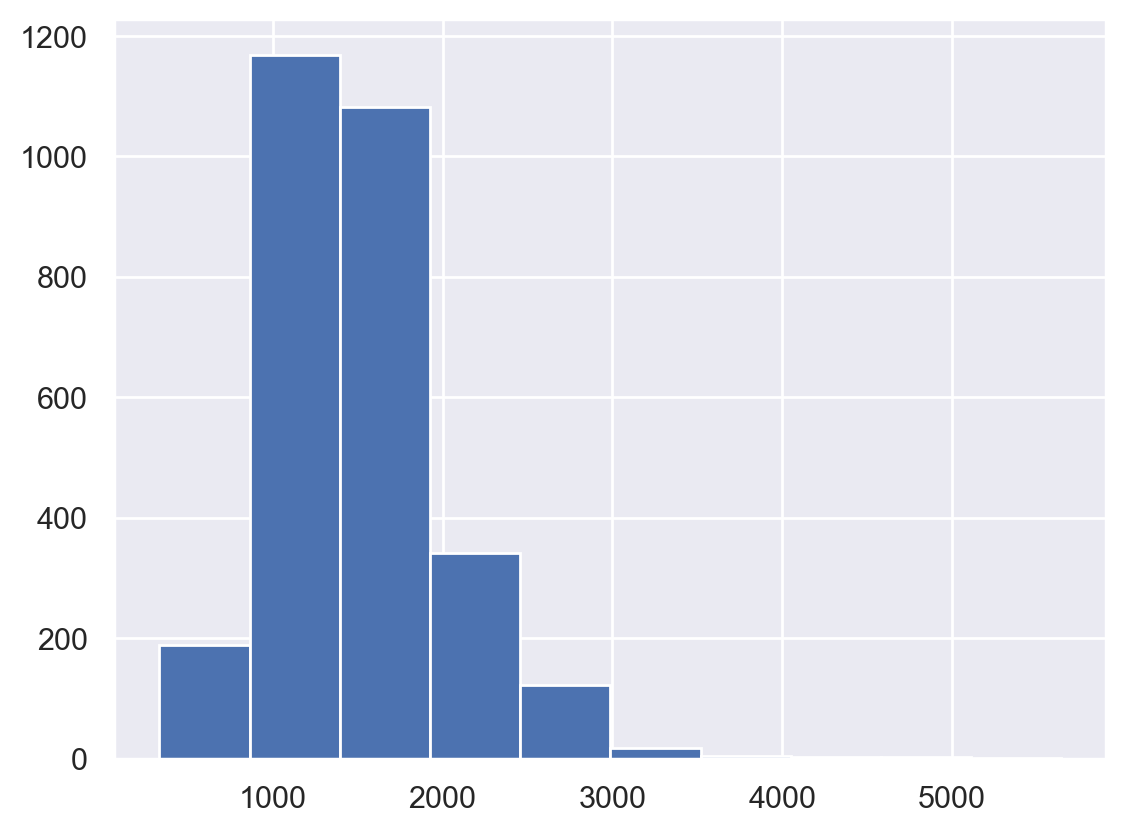

In [7]:
df['Gr Liv Area'].hist() #Histoograma 

In [81]:
# This is recommended by the data set author to remove a few outliers

df = df.loc[df['Gr Liv Area'] <= 4000,:]
print("Number of rows in the data:", df.shape[0]) #hay 2930 filas en el DataFrame original
print("Number of columns in the data:", df.shape[1])
data = df.copy() # Keep a copy our original data 

Number of rows in the data: 2925
Number of columns in the data: 82


In [17]:
# A quick look at the data:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [83]:
df.drop(['Order', 'PID'], axis = 1, inplace=True) #Eliminamos las columnas que no nos sirven

Primero vamos a realizar una limpieza básica de estos datos:

* Conversión de variables categóricas a variables ficticias
* Hacer que las variables sesgadas sean simétricas
### Codificación one-hot para variables ficticias: 

In [ ]:
# Get a Pd.Series consisting of all the string categoricals
one_hot_encode_cols = df.dtypes[df.dtypes == np.object]  # filtering by string categoricals
one_hot_encode_cols = one_hot_encode_cols.index.tolist()  # list of categorical fields

df[one_hot_encode_cols].head().T

We're going to first do some basic data cleaning on this data: 

* Converting categorical variables to dummies
* Making skew variables symmetric

#### One-hot encoding the dummy variables:

In [ ]:
# Do the one hot encoding
df = pd.get_dummies(df, columns=one_hot_encode_cols, drop_first=True)
df.describe().T

### Log transforming skew variables

In [31]:
df.select_dtypes('number') #Columnas con valor numérico, con esto obtienes un Datafra,e

,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,20,141.0,31770,6,5,1960,1960,112.0,639.0,0.0,...,210,62,0,0,0,0,0,5,2010,215000
1,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,...,140,0,0,0,120,0,0,6,2010,105000
2,20,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,...,393,36,0,0,0,0,12500,6,2010,172000
3,20,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,...,0,0,0,0,0,0,0,4,2010,244000
4,60,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,...,212,34,0,0,0,0,0,3,2010,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,80,37.0,7937,6,6,1984,1984,0.0,819.0,0.0,...,120,0,0,0,0,0,0,3,2006,142500
2926,20,NaN,8885,5,5,1983,1983,0.0,301.0,324.0,...,164,0,0,0,0,0,0,6,2006,131000
2927,85,62.0,10441,5,5,1992,1992,0.0,337.0,0.0,...,80,32,0,0,0,0,700,7,2006,132000
2928,20,77.0,10010,5,5,1974,1975,0.0,1071.0,123.0,...,240,38,0,0,0,0,0,4,2006,170000


In [33]:
df.select_dtypes('object') #Columnas con valor object

,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
0,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Attchd,Fin,TA,TA,P,NaN,NaN,NaN,WD,Normal
1,RH,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,...,Attchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,NaN,NaN,Gar2,WD,Normal
3,RL,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Attchd,Fin,TA,TA,Y,NaN,NaN,NaN,WD,Normal
4,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,Attchd,Fin,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,RL,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,Mitchel,Norm,...,Detchd,Unf,TA,TA,Y,NaN,GdPrv,NaN,WD,Normal
2926,RL,Pave,NaN,IR1,Low,AllPub,Inside,Mod,Mitchel,Norm,...,Attchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
2927,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,...,NaN,NaN,NaN,NaN,Y,NaN,MnPrv,Shed,WD,Normal
2928,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


In [35]:
df.select_dtypes('number').columns

Index(['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area',
       'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area',
       'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath',
       'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces',
       'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF',
       'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
       'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice'],
      dtype='object')

**Interpretación del coeficiente de asimetría (`skew`)**

$$
\text{skew} > 0 \quad \Rightarrow \quad \text{sesgo a la derecha}
$$

$$
\text{skew} < 0 \quad \Rightarrow \quad \text{sesgo a la izquierda}
$$

$$
\text{skew} = 0 \quad \Rightarrow \quad \text{distribución simétrica}
$$


In [51]:
# Seleccionamos las columnas numéricas del DataFrame
float_cols = df.select_dtypes('number').columns

# Definimos un umbral de asimetría (skewness) por encima del cual aplicaremos
# una transformación logarítmica para reducir la asimetría
skew_limit = 0.75

# Calculamos la asimetría (skewness) de todas las columnas numéricas
skew_vals = df[float_cols].skew()

# Mostramos los valores de asimetría
skew_vals


MS SubClass         1.356549
Lot Frontage        1.111071
Lot Area           13.200004
Overall Qual        0.171657
Overall Cond        0.572769
Year Built         -0.602475
Year Remod/Add     -0.449567
Mas Vnr Area        2.565458
BsmtFin SF 1        0.821985
BsmtFin SF 2        4.135900
Bsmt Unf SF         0.925021
Total Bsmt SF       0.399079
1st Flr SF          0.942615
2nd Flr SF          0.847517
Low Qual Fin SF    12.107629
Gr Liv Area         0.878879
Bsmt Full Bath      0.615553
Bsmt Half Bath      3.965970
Full Bath           0.164954
Half Bath           0.702966
Bedroom AbvGr       0.306912
Kitchen AbvGr       4.309573
TotRms AbvGrd       0.704992
Fireplaces          0.732312
Garage Yr Blt      -0.382039
Garage Cars        -0.219734
Garage Area         0.213681
Wood Deck SF        1.848286
Open Porch SF       2.495162
Enclosed Porch      4.010586
3Ssn Porch         11.393854
Screen Porch        3.953495
Pool Area          18.743766
Misc Val           22.225015
Mo Sold       

In [49]:
# Mostramos las columnas que presentan asimetría significativa

# Tomamos los valores de skew, los ordenamos de mayor a menor,
# los convertimos en un DataFrame, renombramos la columna a 'Skew'
# y filtramos solo aquellas columnas cuyo valor absoluto de skew  supera el umbral definido (skew_limit)
skew_cols = (skew_vals
             .sort_values(ascending=False)      # Ordenar por asimetría descendente
             .to_frame()                        # Convertir a DataFrame
             .rename(columns={0: 'Skew'})       # Renombrar la columna resultante
             .query('abs(Skew) > {}'.format(skew_limit))  # Filtrar columnas muy asimétricas
            )

# Mostrar el DataFrame resultante con las columnas sesgadas
skew_cols


,Skew
Misc Val,22.225015
Pool Area,18.743766
Lot Area,13.200004
Low Qual Fin SF,12.107629
3Ssn Porch,11.393854
Kitchen AbvGr,4.309573
BsmtFin SF 2,4.135900
Enclosed Porch,4.010586
Bsmt Half Bath,3.965970
Screen Porch,3.953495


Asimetría skew: 1.5910724110509824>0 entonces, sesgada a la derecha
 


Text(0.5, 0.98, 'Field "SalePrice"')

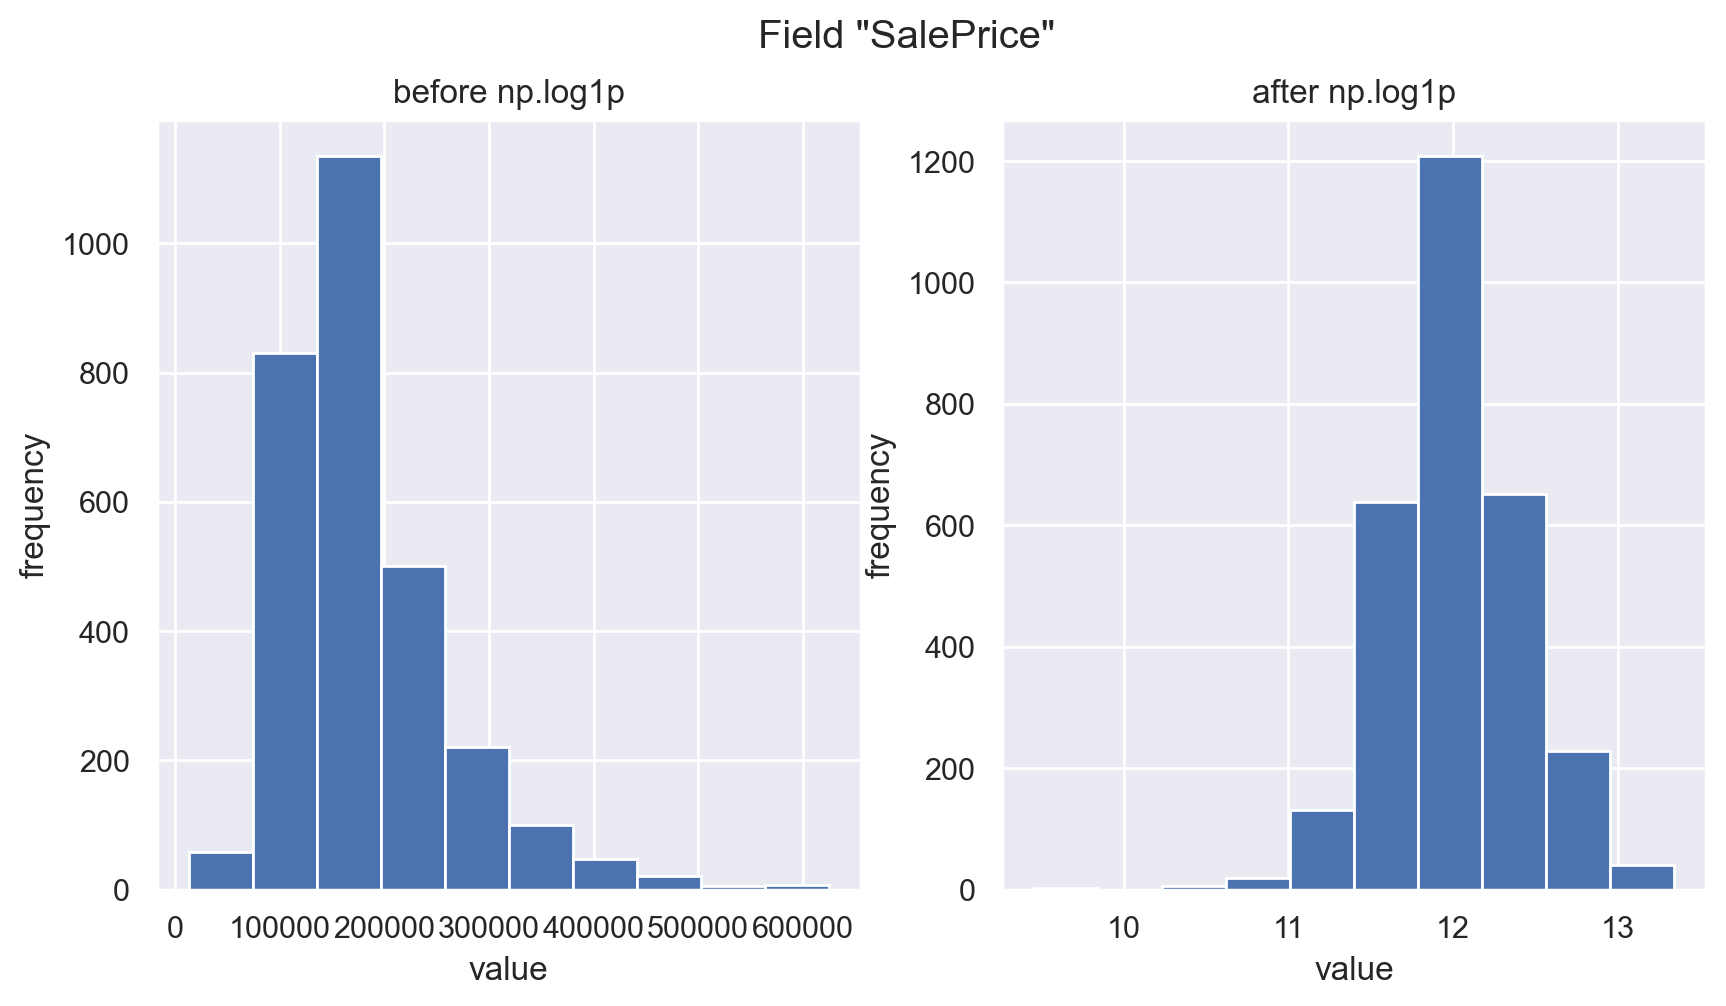

In [67]:
# Vamos a visualizar qué ocurre con una de estas variables cuando aplicamos np.log1p

# Elegimos un campo/columna sobre el que hacer la comparación
field = "SalePrice"

# Calculamos la asimetría (skewness) de todas las columnas numéricas
skew_vals = df[field].skew()
print(f"Asimetría skew: {skew_vals}>0 entonces, sesgada a la derecha\n ")

# Creamos una figura con dos subplots (dos gráficos lado a lado)
fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(10, 5))

# Dibujamos un histograma del campo original en el subplot ax_before
df[field].hist(ax=ax_before)

# Aplicamos la transformación logarítmica np.log1p (log(1+x)) y dibujamos su histograma en ax_after
df[field].apply(np.log1p).hist(ax=ax_after)

# Ajustes visuales: títulos y etiquetas para cada subplot
ax_before.set(title='before np.log1p', ylabel='frequency', xlabel='value')
ax_after.set(title='after np.log1p', ylabel='frequency', xlabel='value')

# Título general de la figura
fig.suptitle('Field "{}"'.format(field))


In [95]:
def plot_log_transform_with_skew(df, column):
    """
    Grafica el histograma original y el transformado con np.log1p para una columna,
    y muestra el valor de skew directamente en cada histograma.
    """
    # Calculamos skew del dato original
    skew_before = df[column].skew()
    
    # Calculamos skew del dato transformado con log1p
    skew_after = df[column].apply(np.log1p).skew()
    
    # Creamos dos subplots lado a lado
    fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(10, 5))
    
    # Histograma original
    df[column].hist(ax=ax_before, color='skyblue', edgecolor='black')
    ax_before.set(title='Before np.log1p', ylabel='Frequency', xlabel='Value')
    # Agregamos el valor de skew dentro del subplot
    ax_before.text(0.95, 0.95, f'Skew: {skew_before:.2f}', transform=ax_before.transAxes,
                   ha='right', va='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
    
    # Histograma transformado
    df[column].apply(np.log1p).hist(ax=ax_after, color='lightgreen', edgecolor='black')
    ax_after.set(title='After np.log1p', ylabel='Frequency', xlabel='Value')
    # Agregamos el valor de skew dentro del subplot
    ax_after.text(0.95, 0.95, f'Skew: {skew_after:.2f}', transform=ax_after.transAxes,
                  ha='right', va='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
    
    # Título general de la figura
    fig.suptitle(f'Field "{column}"', fontsize=14)
    
    plt.show()



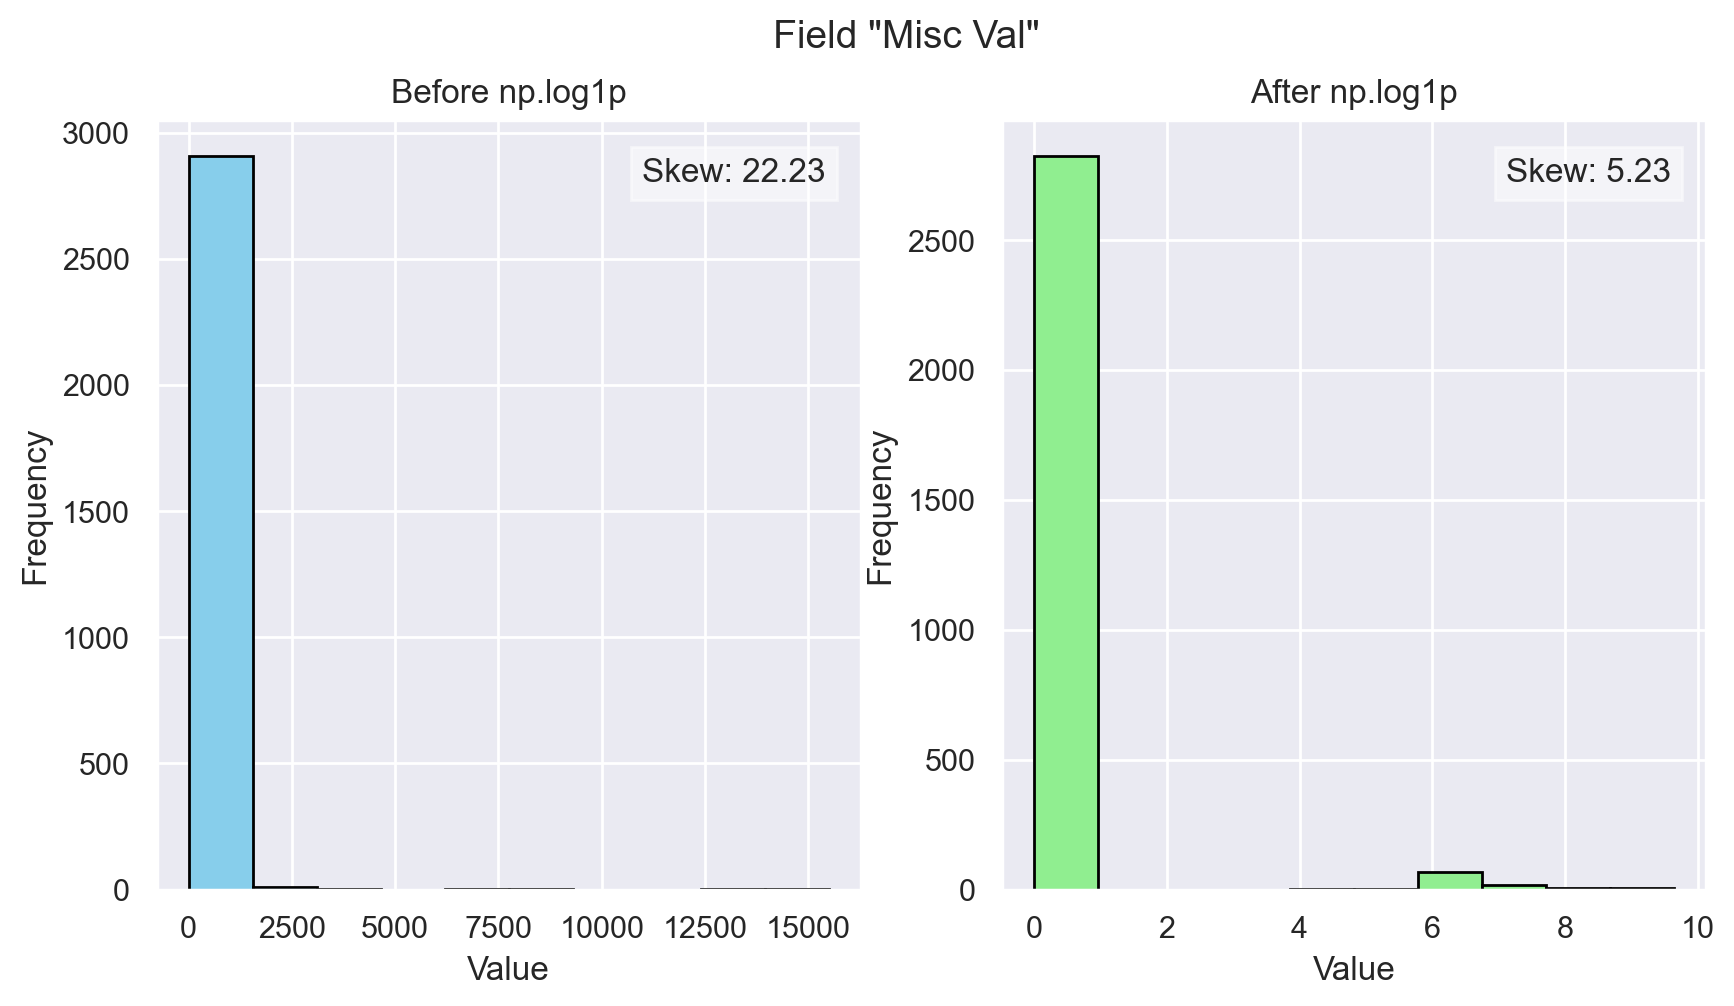

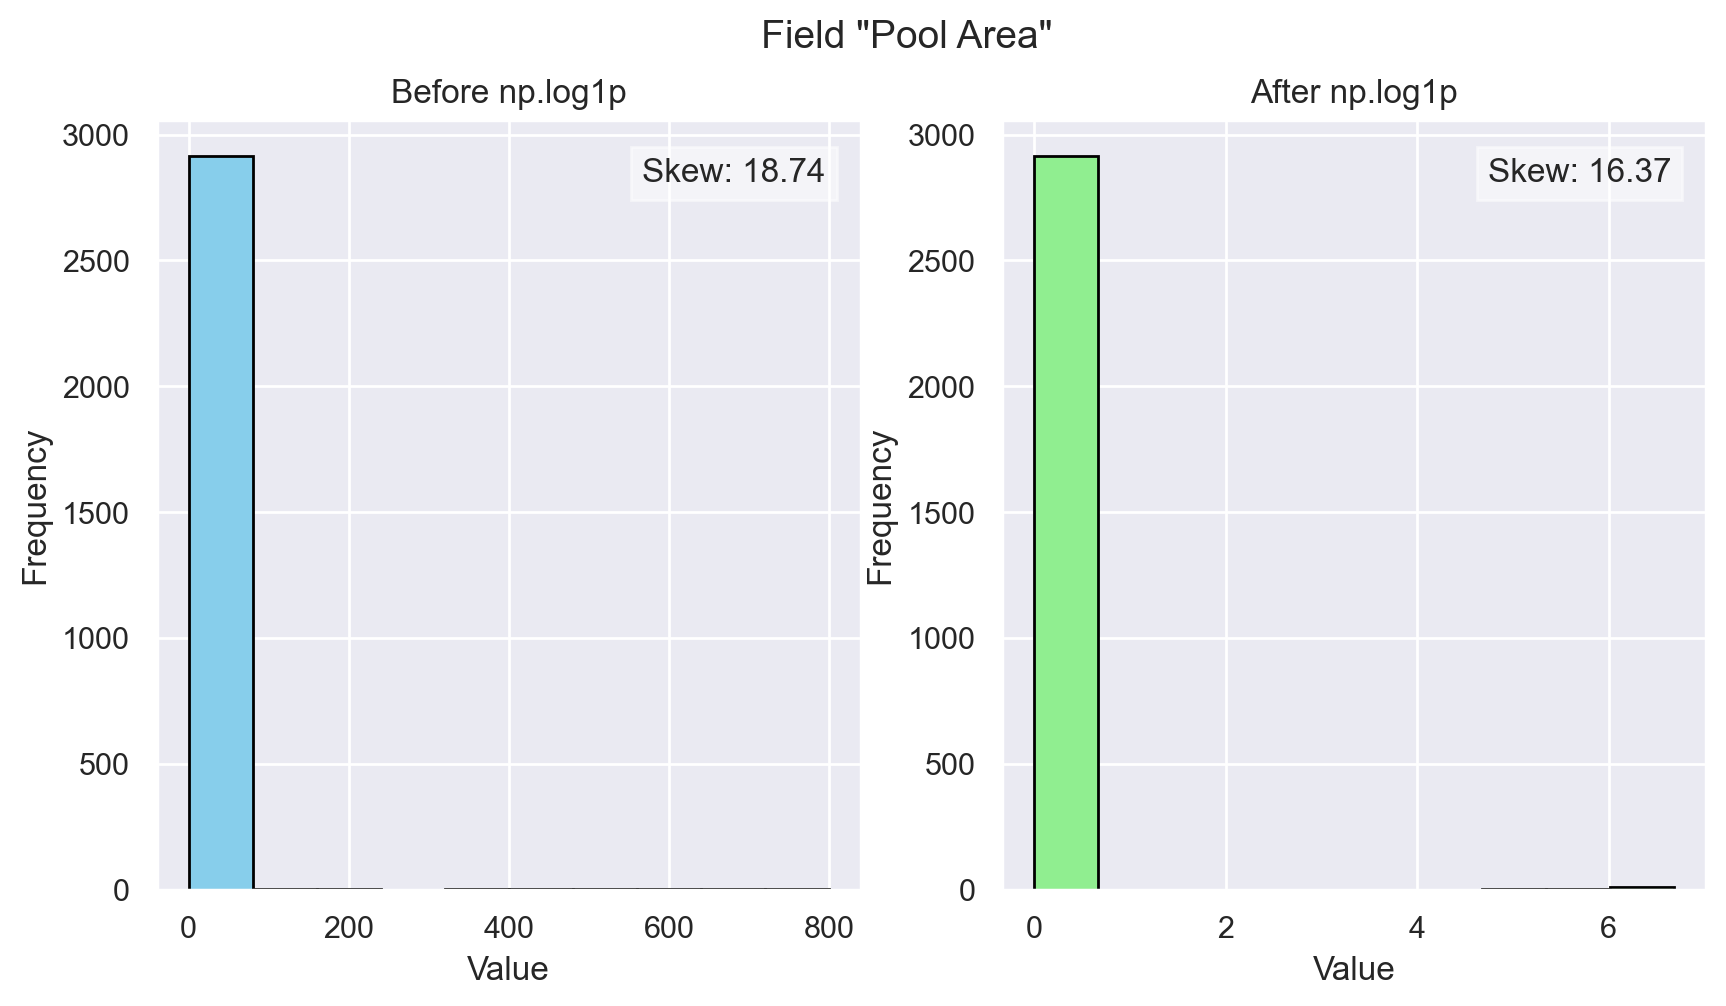

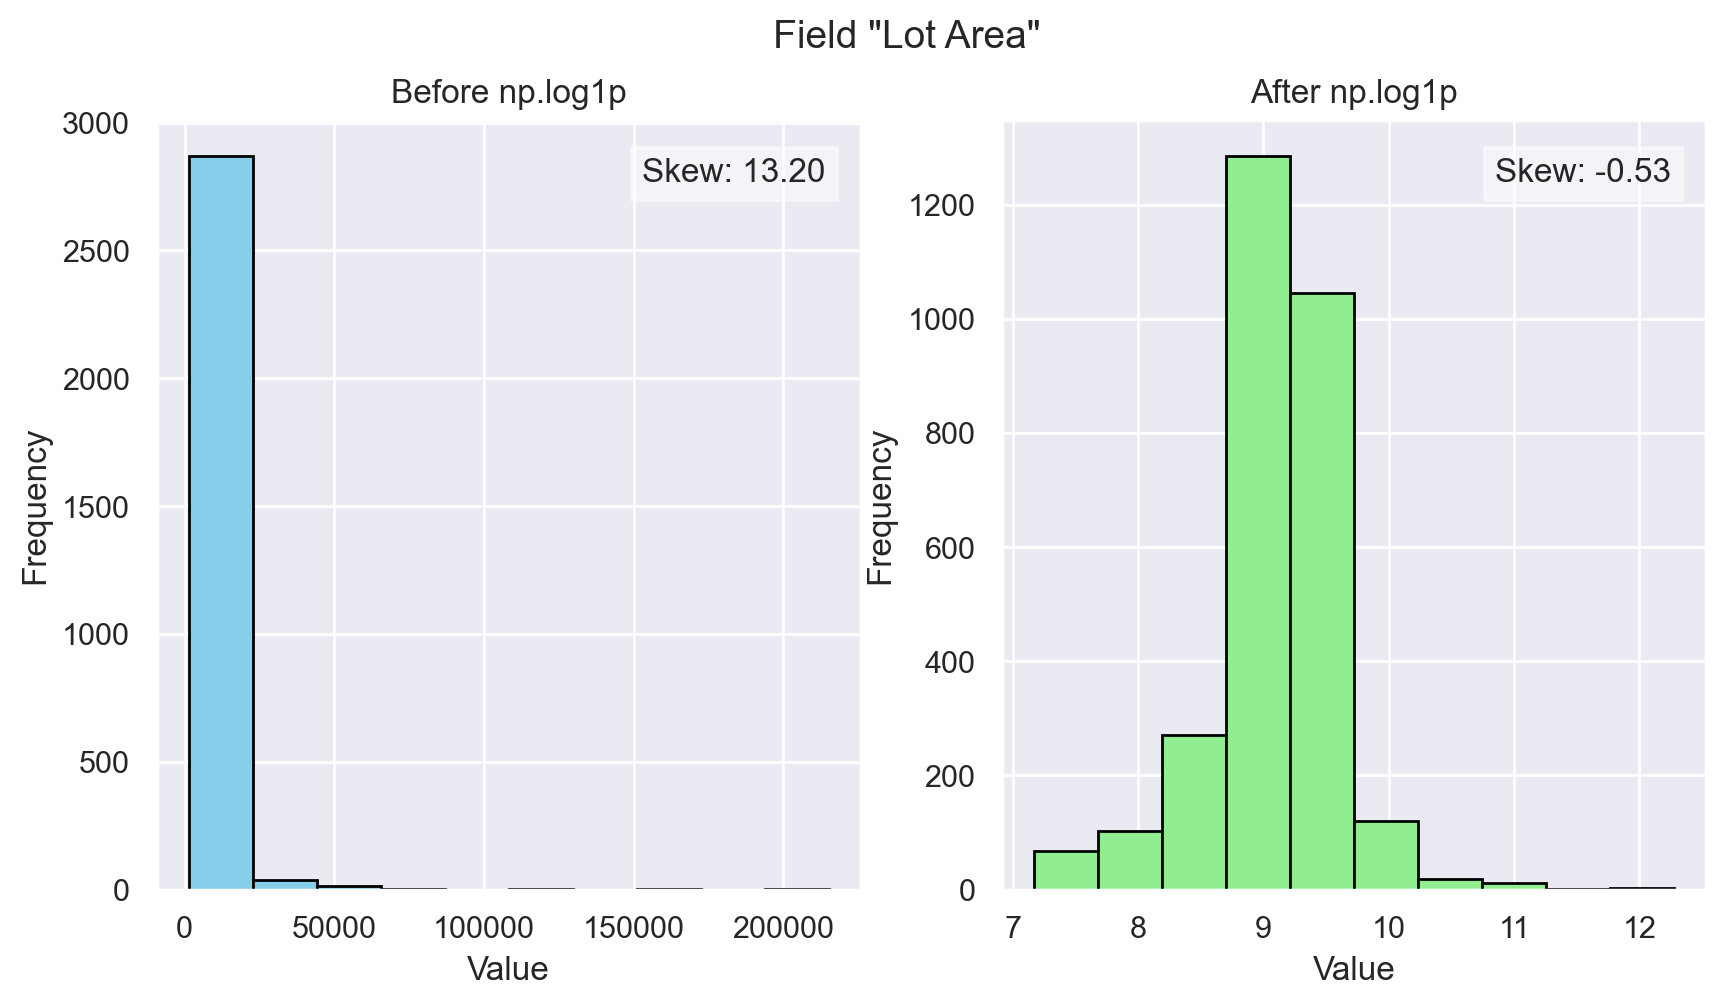

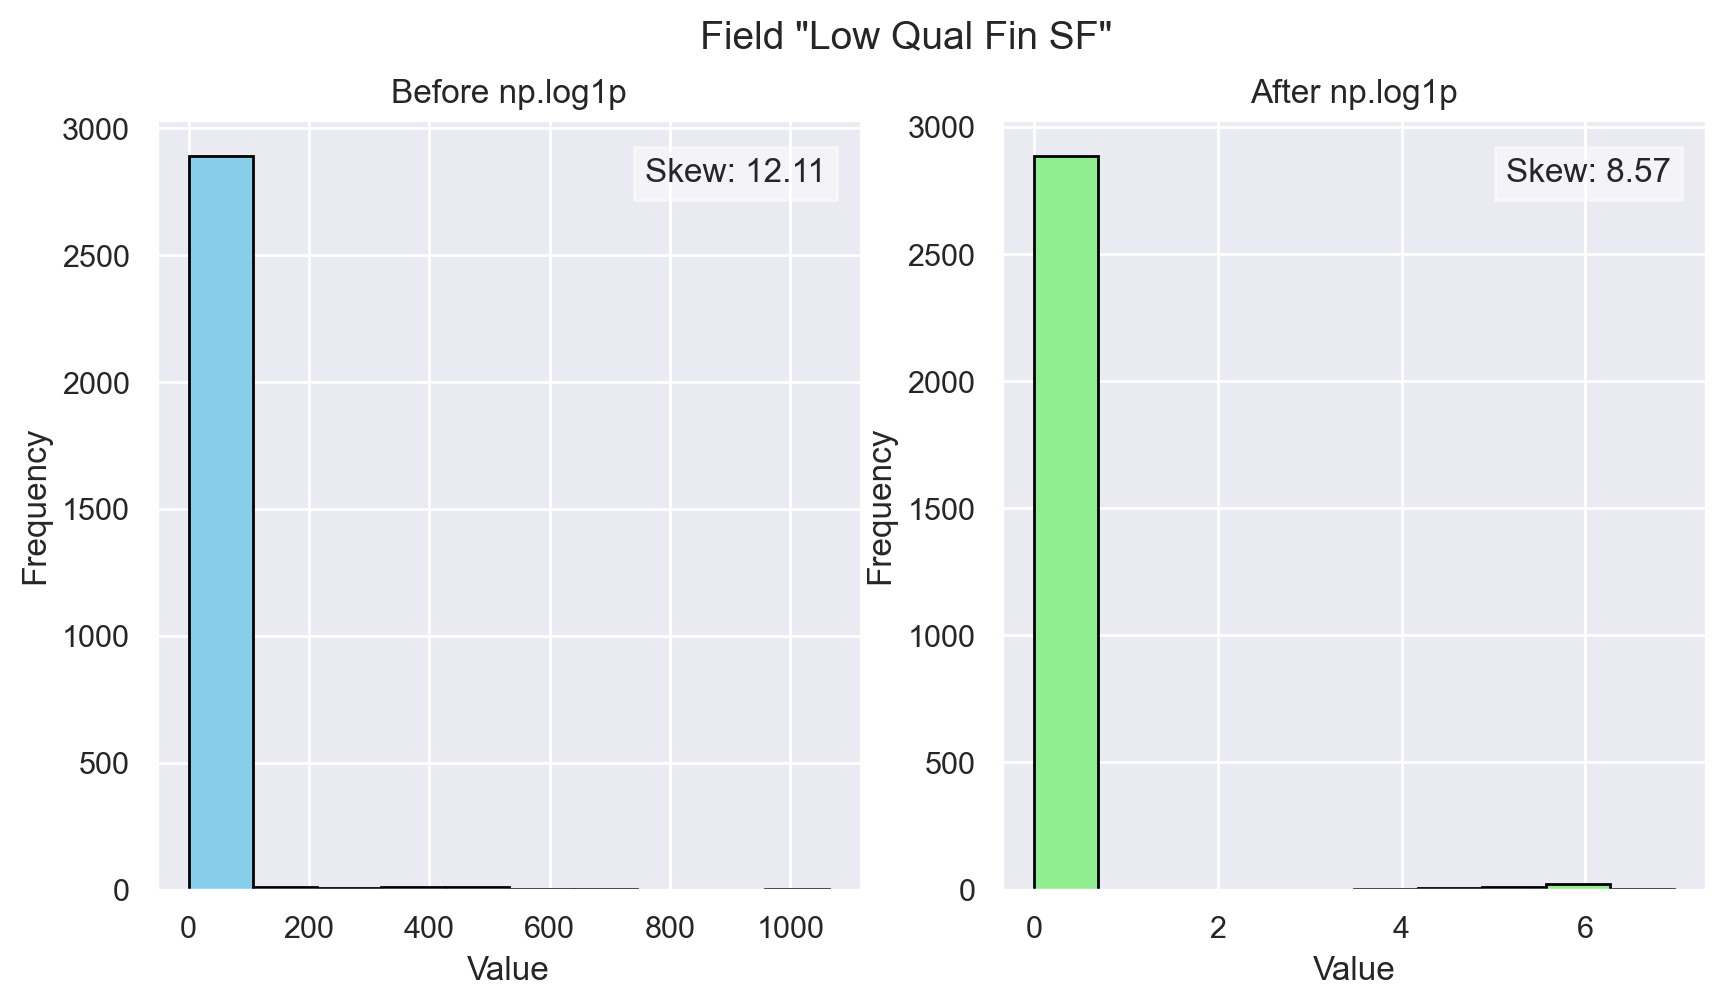

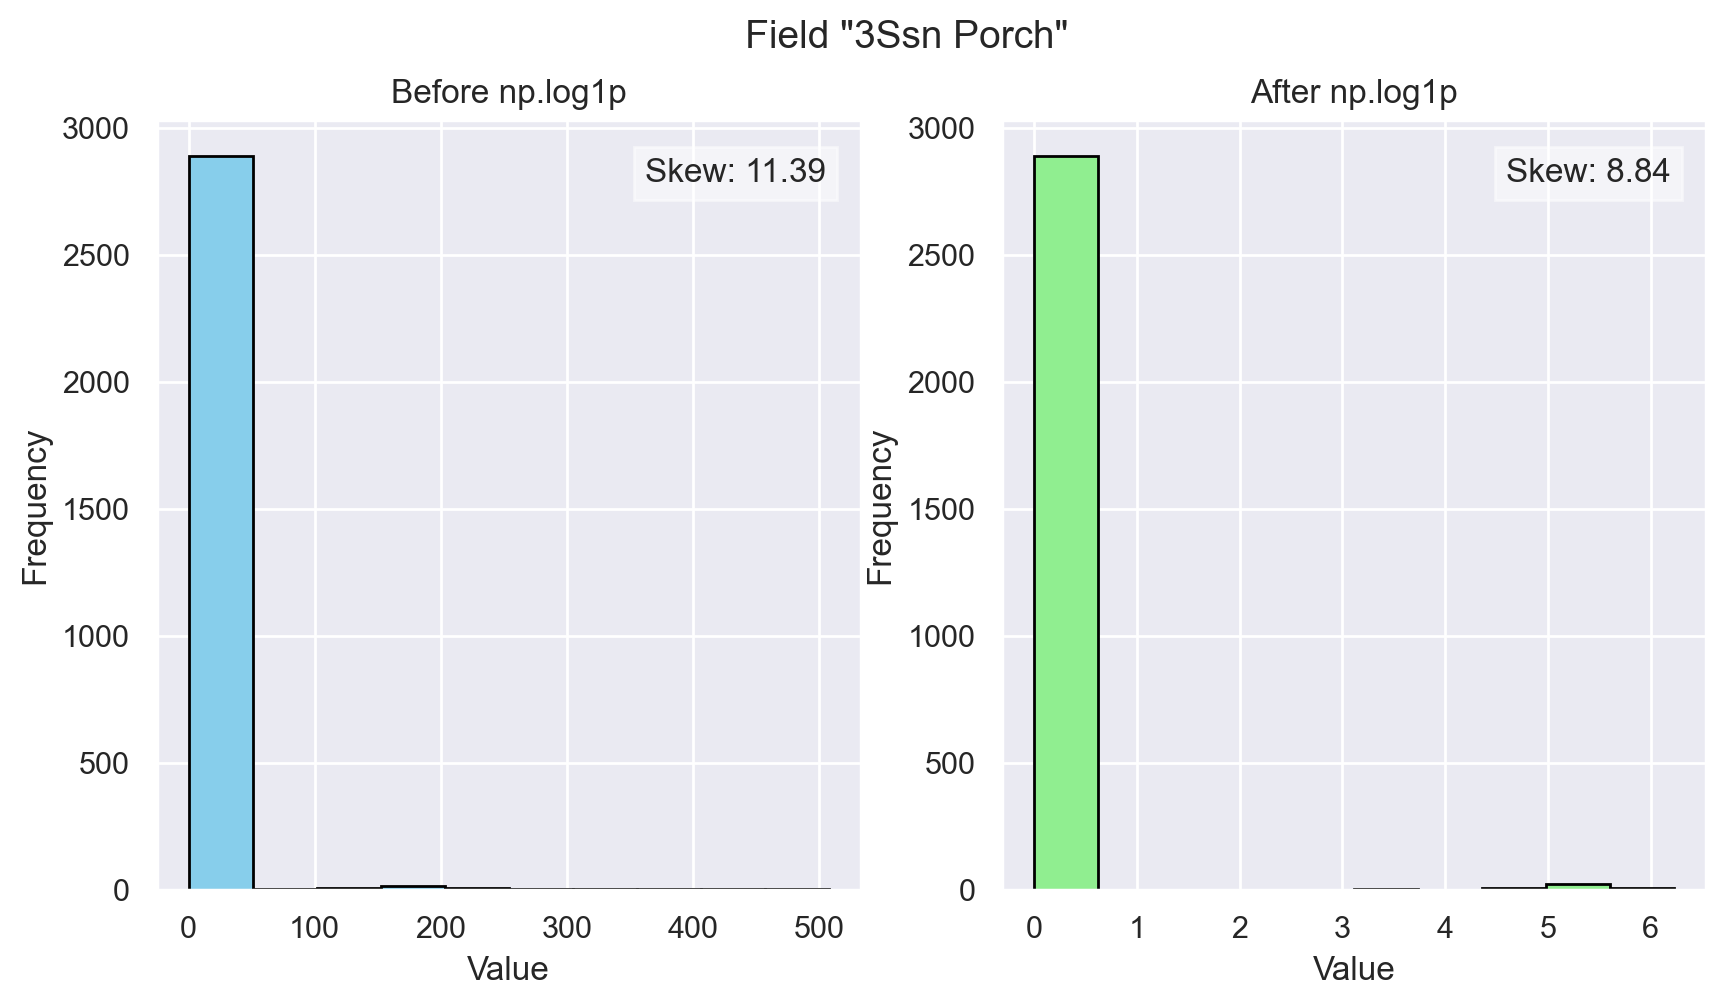

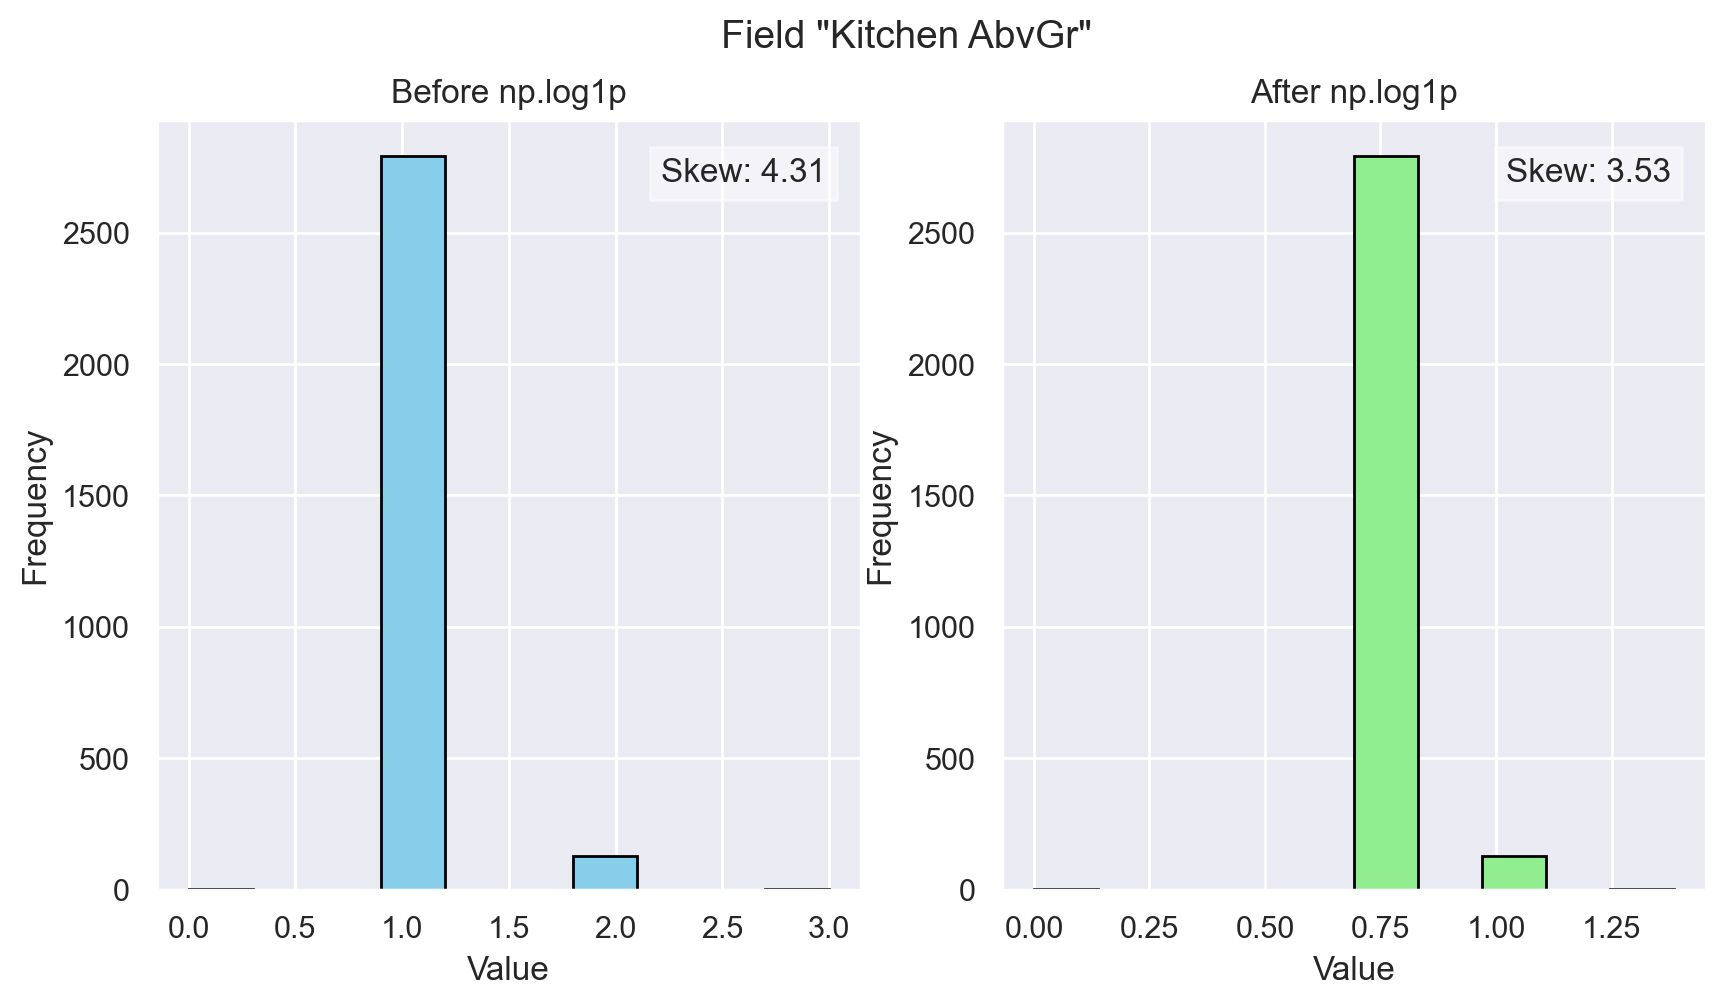

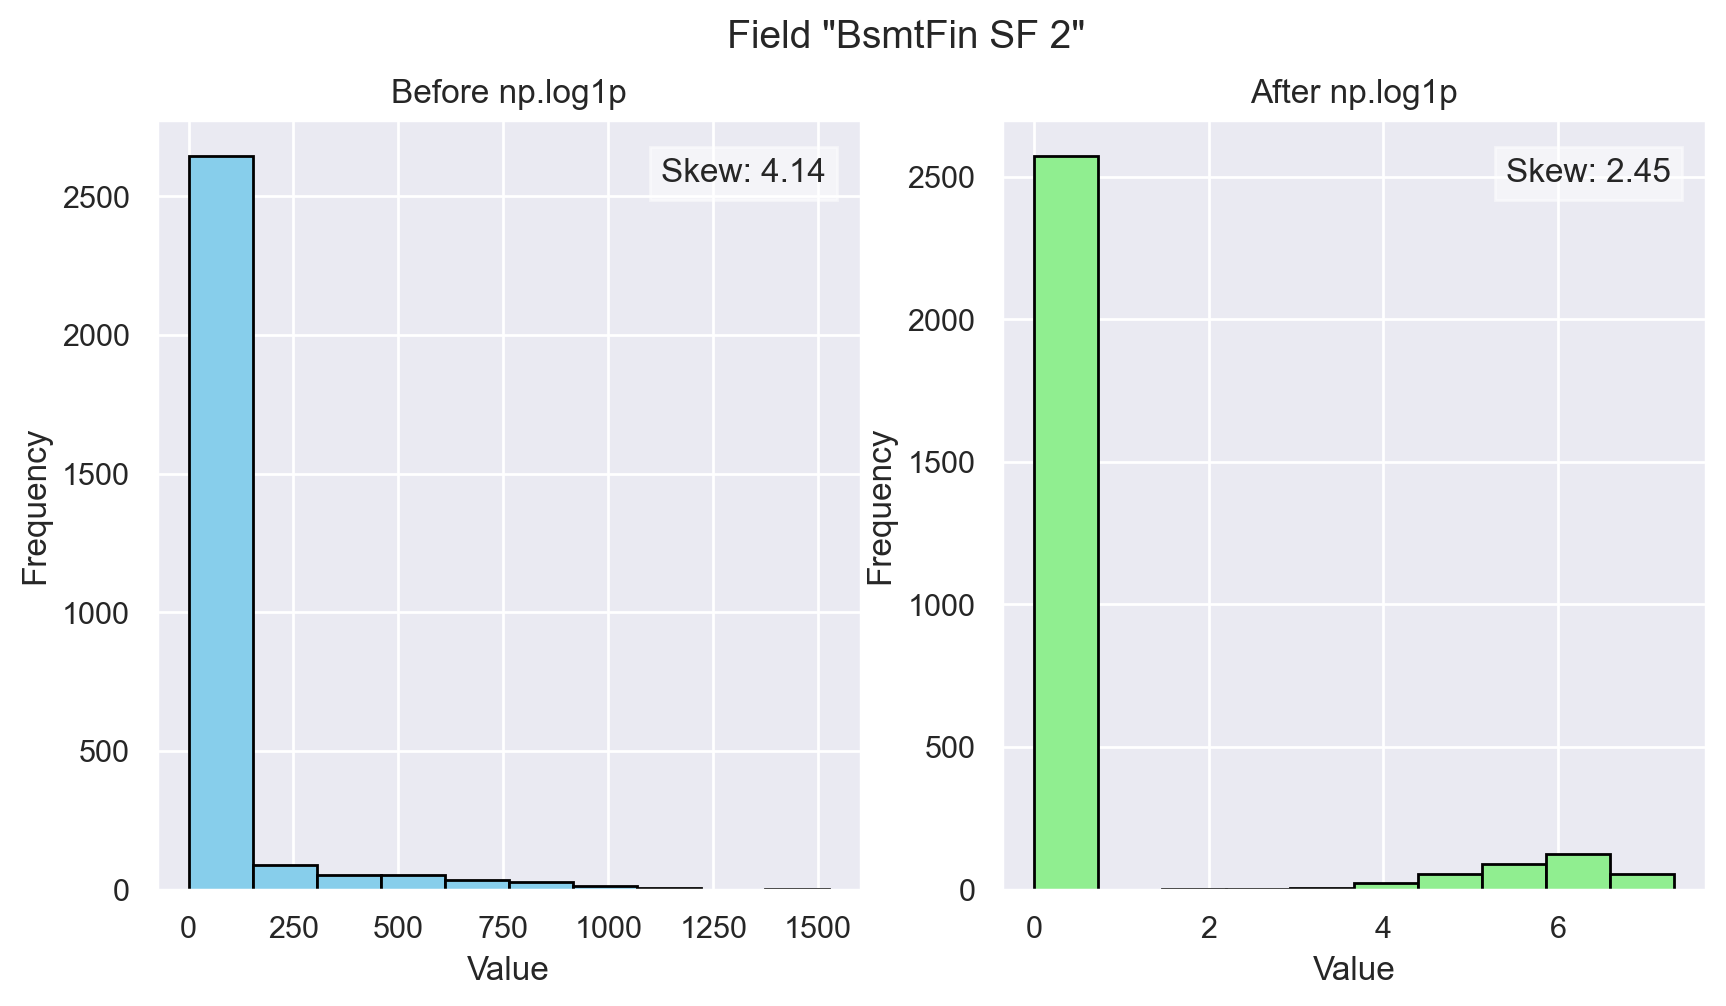

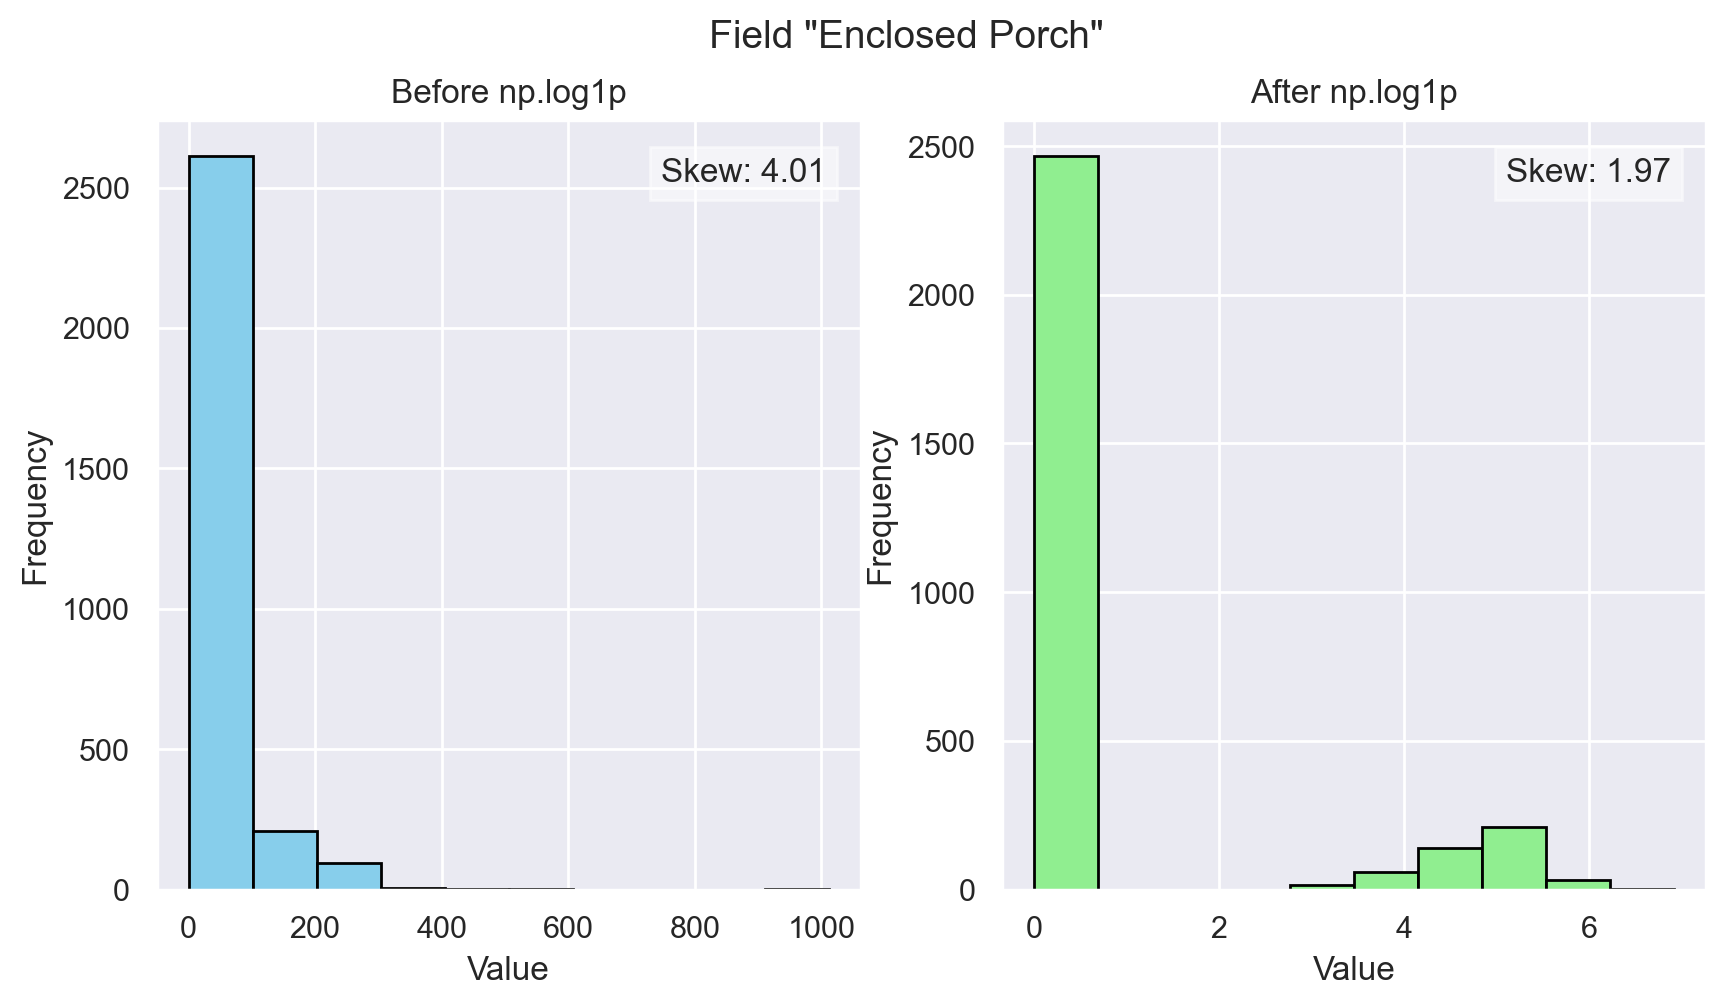

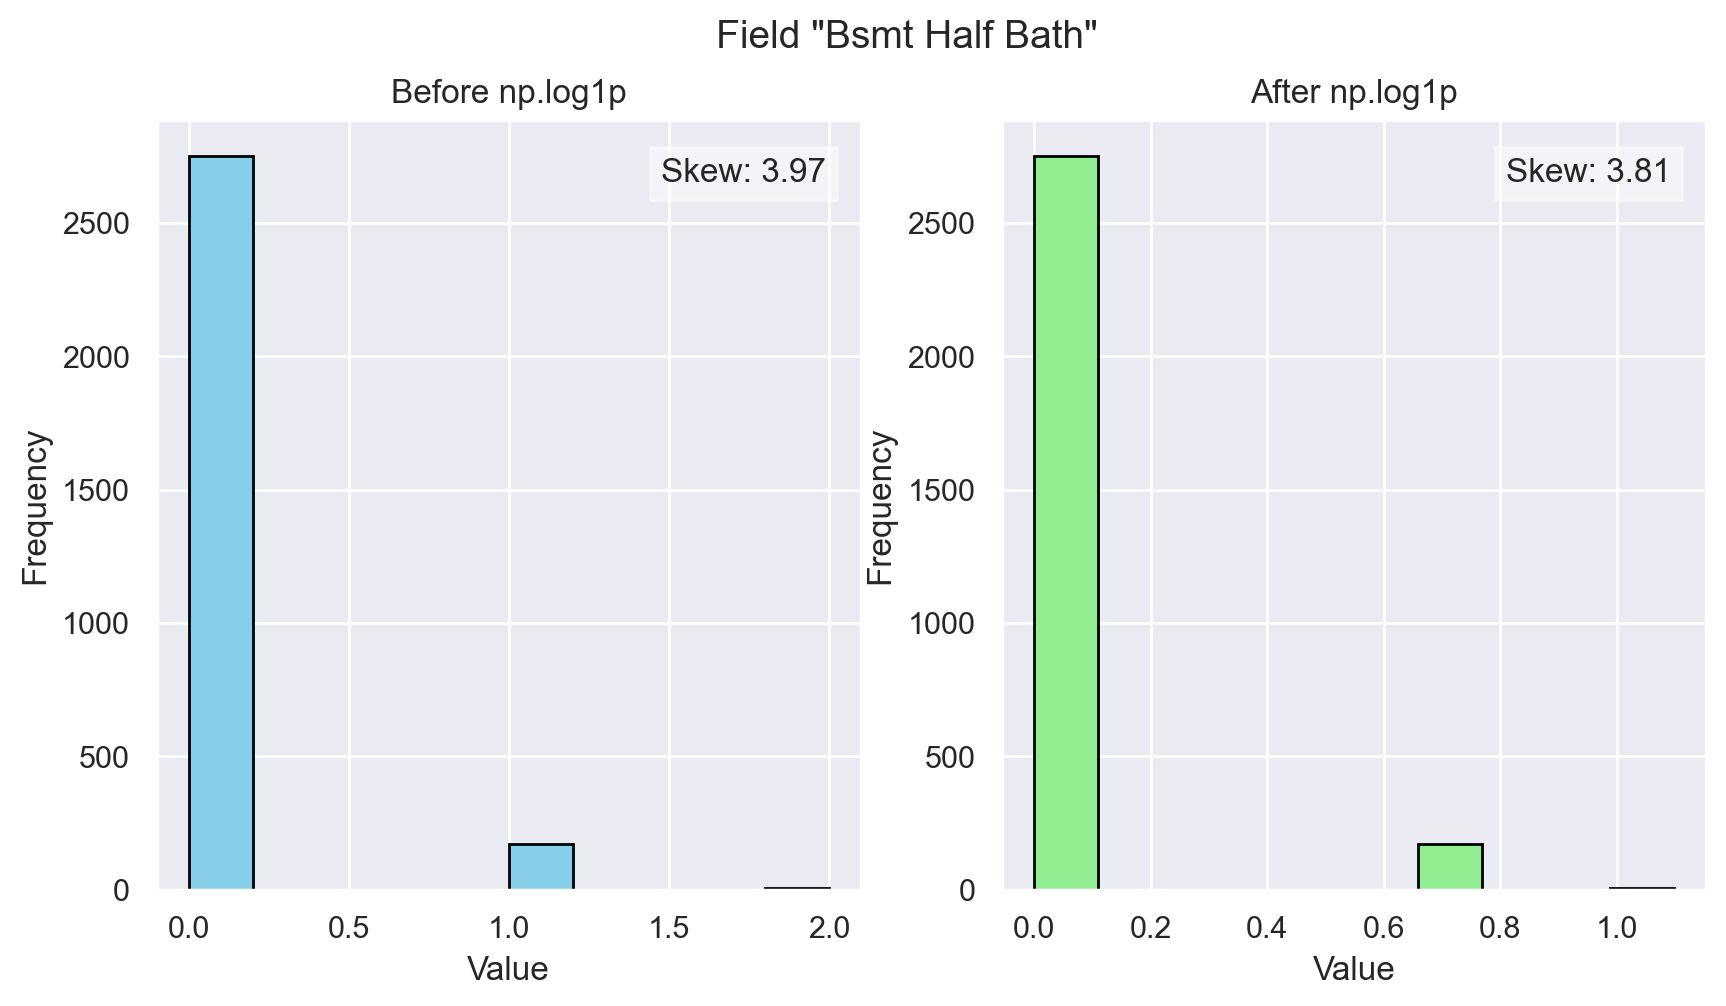

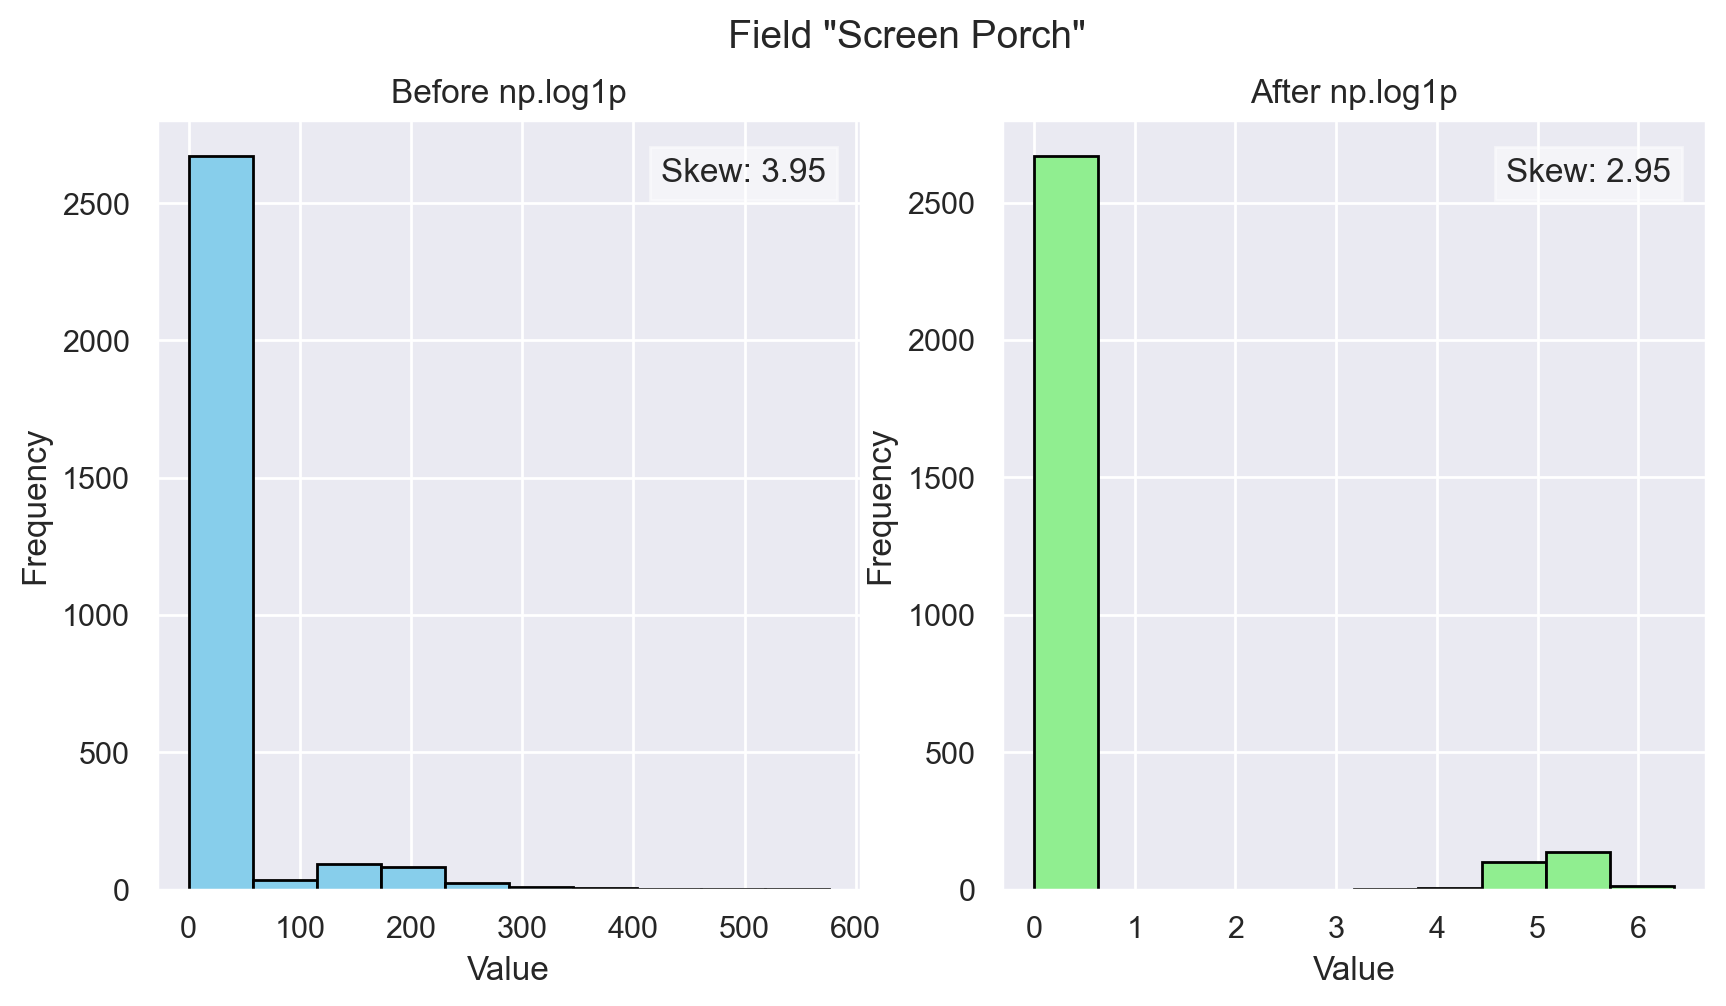

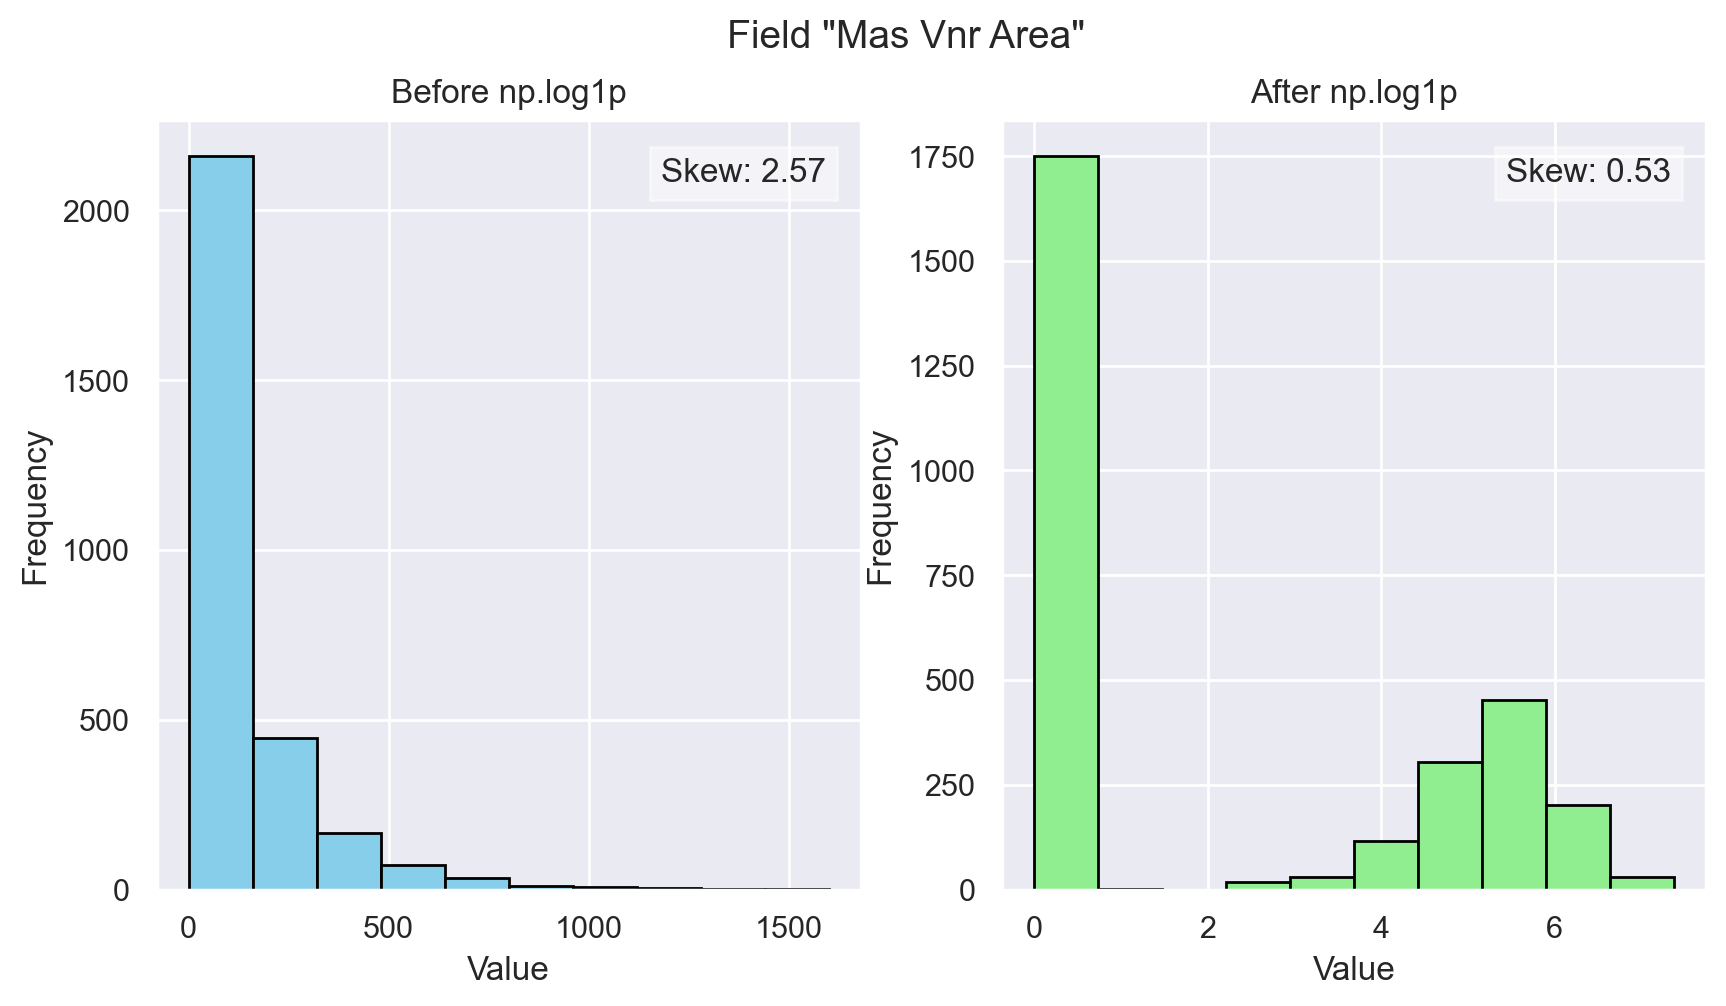

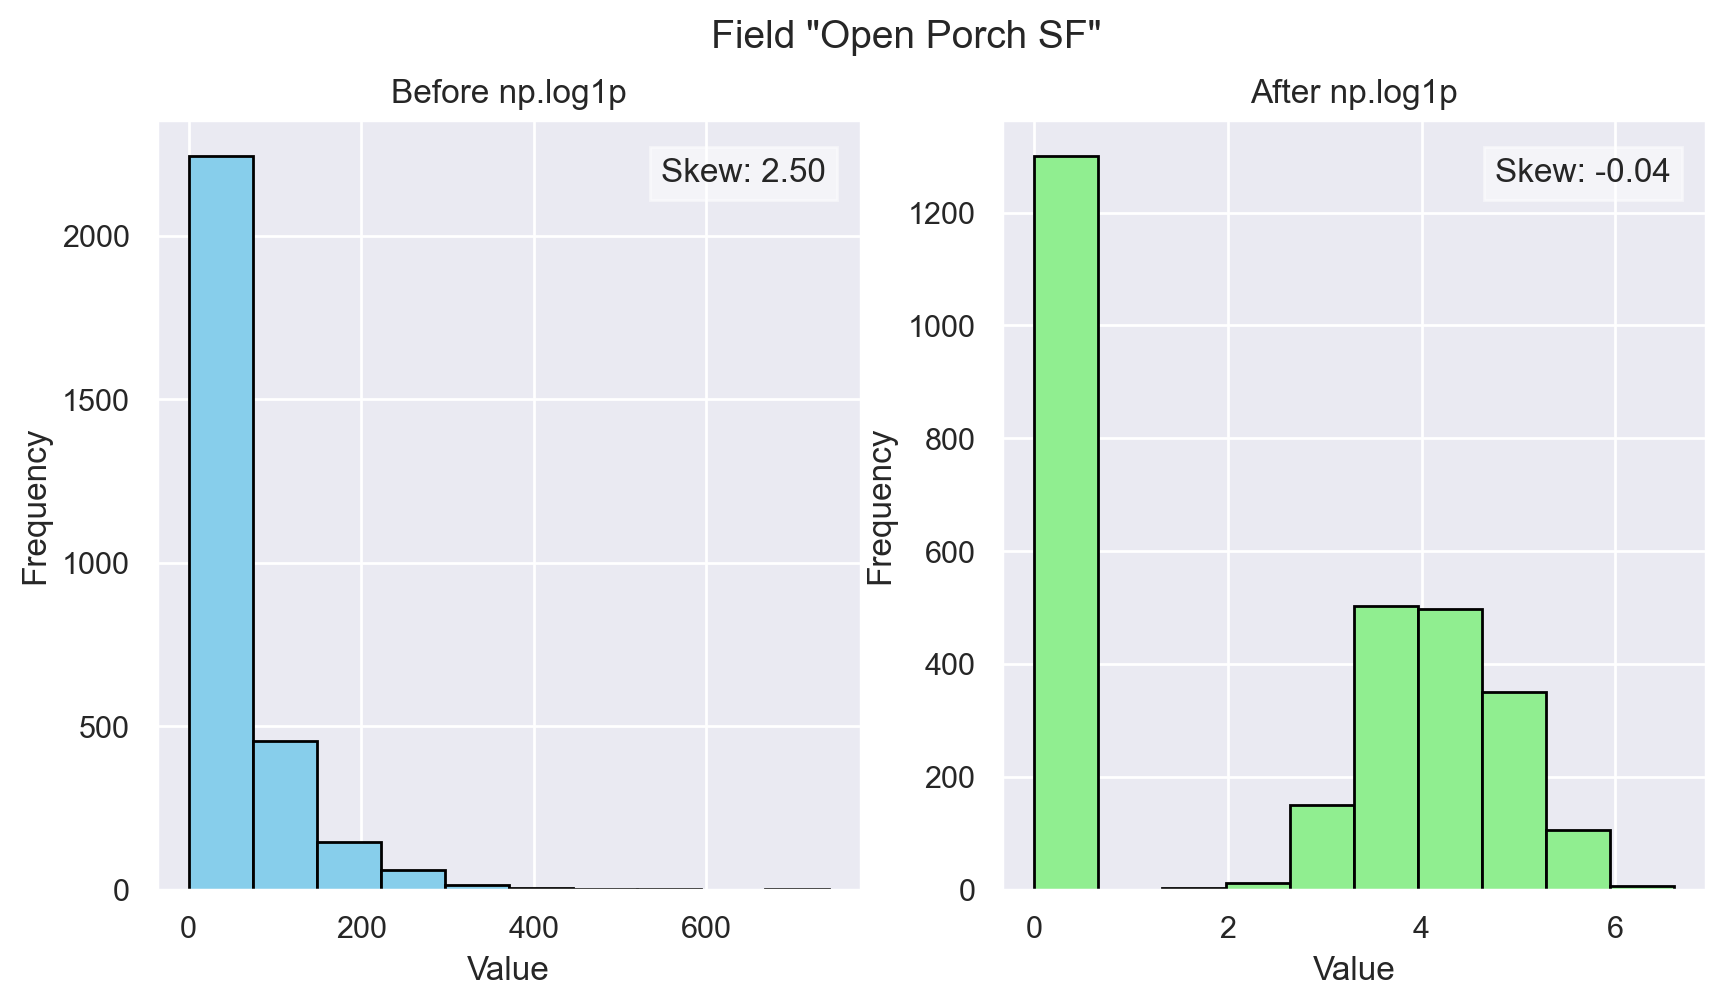

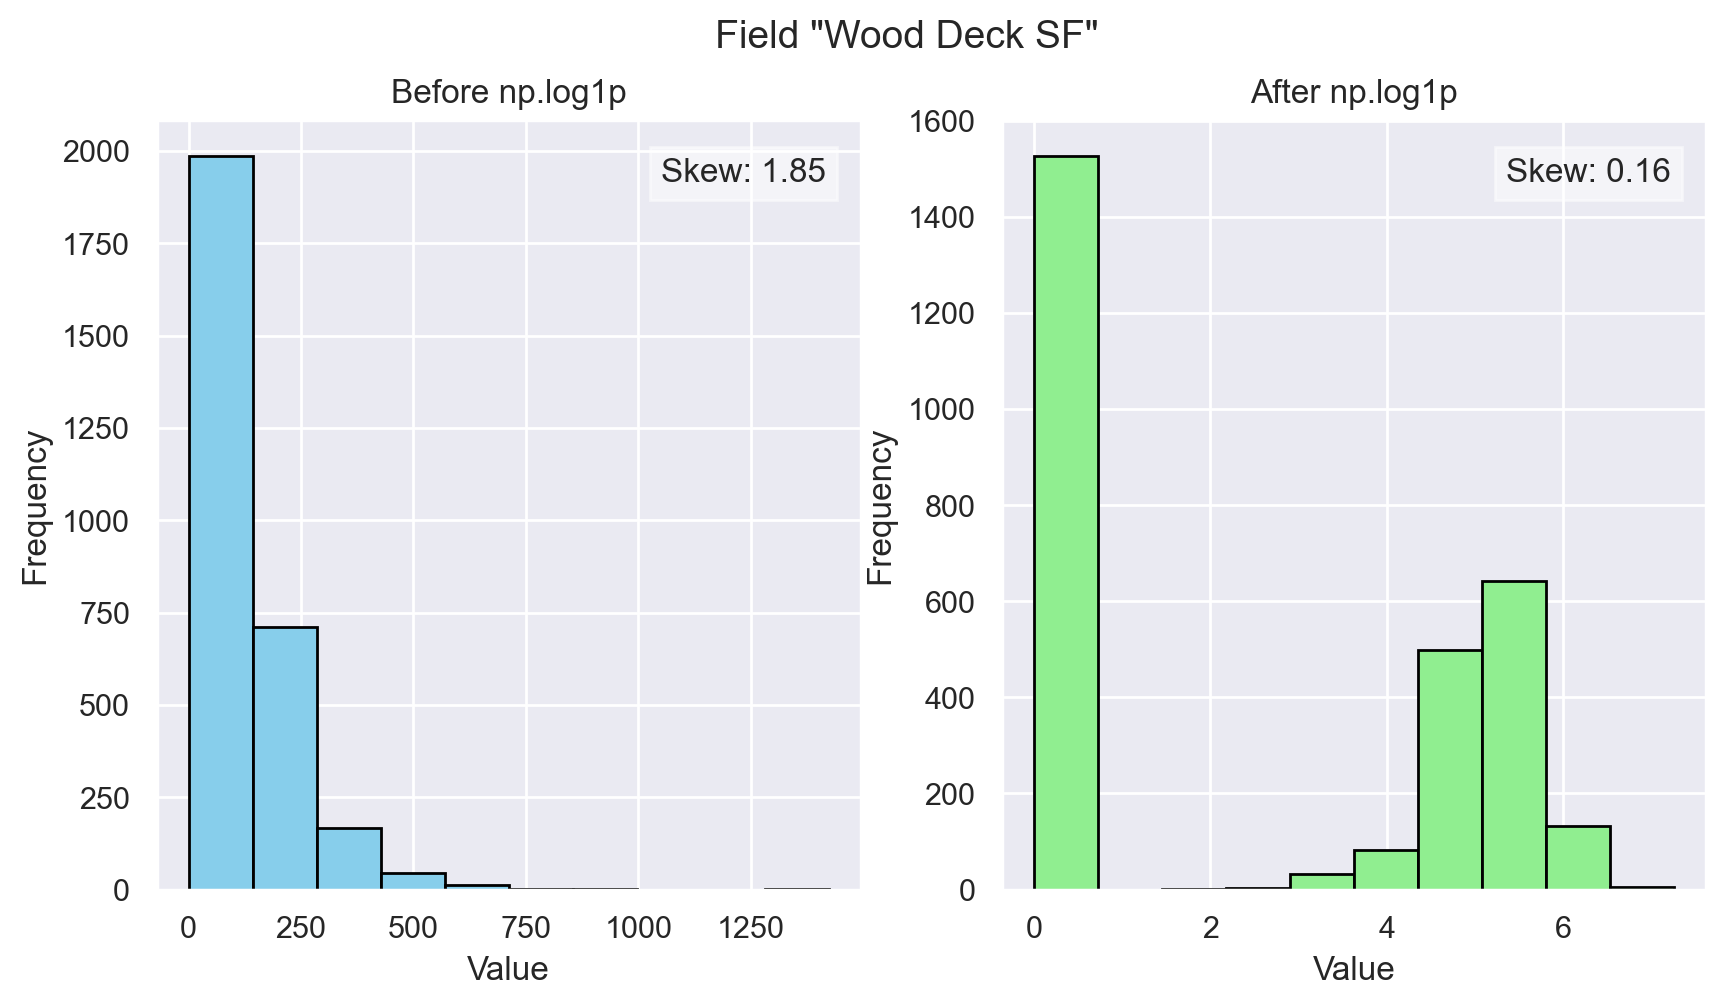

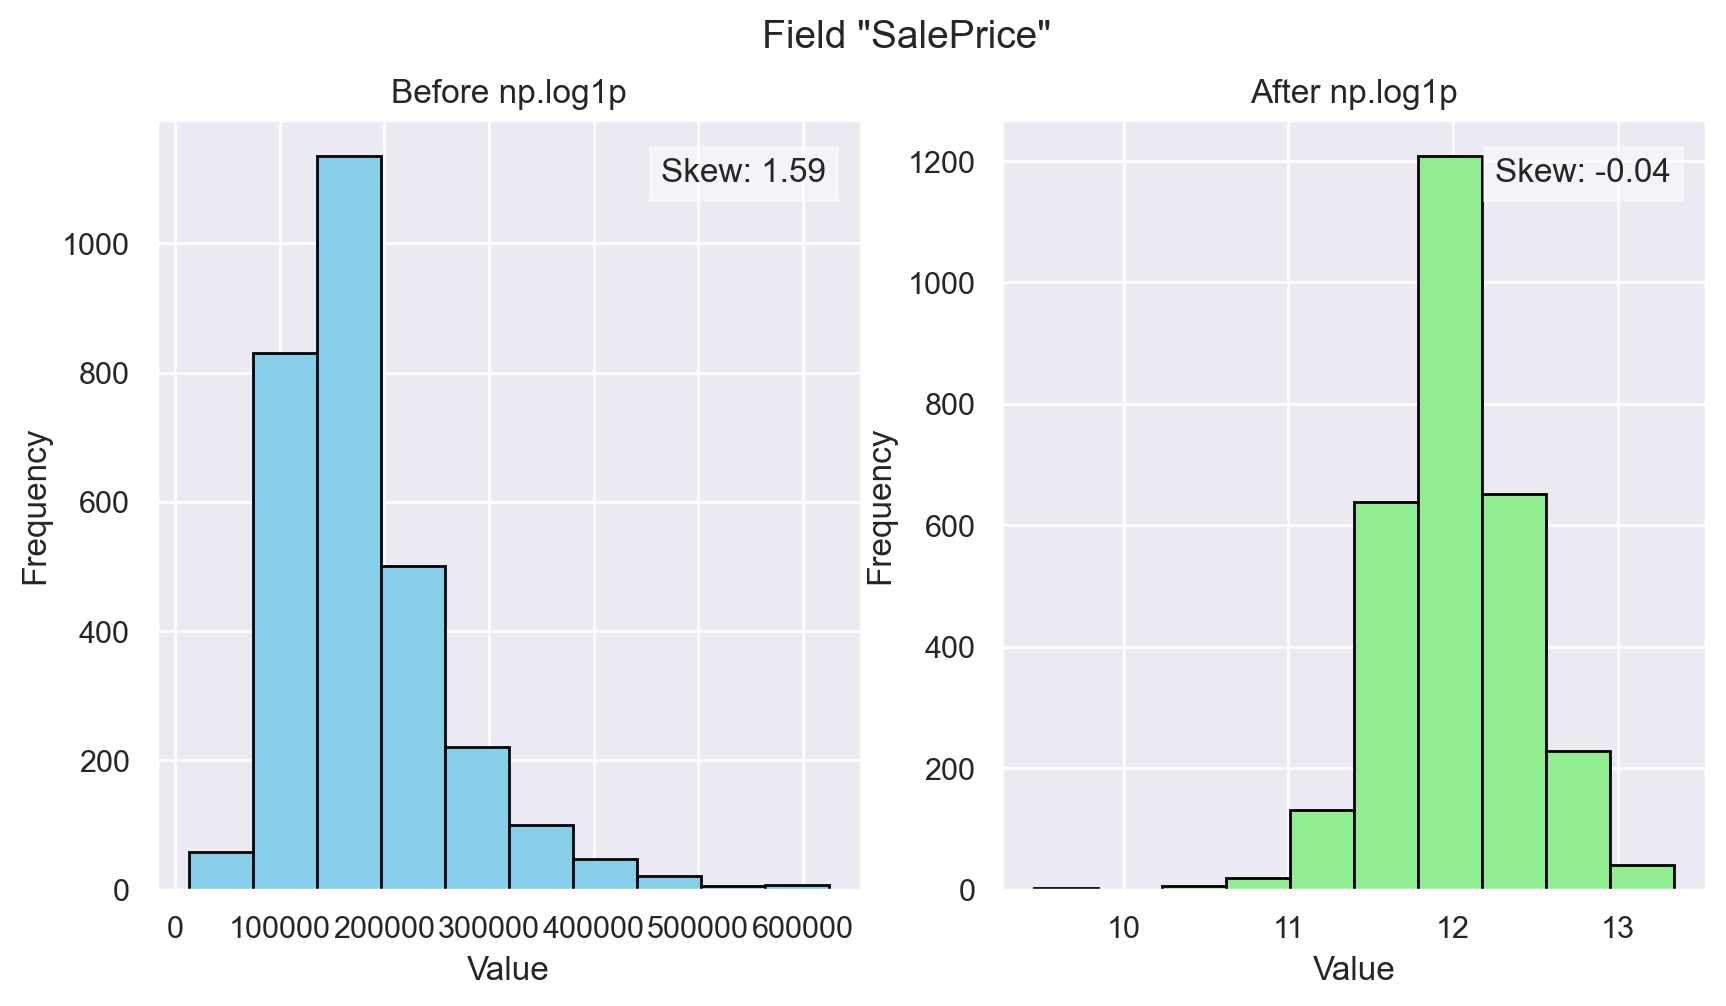

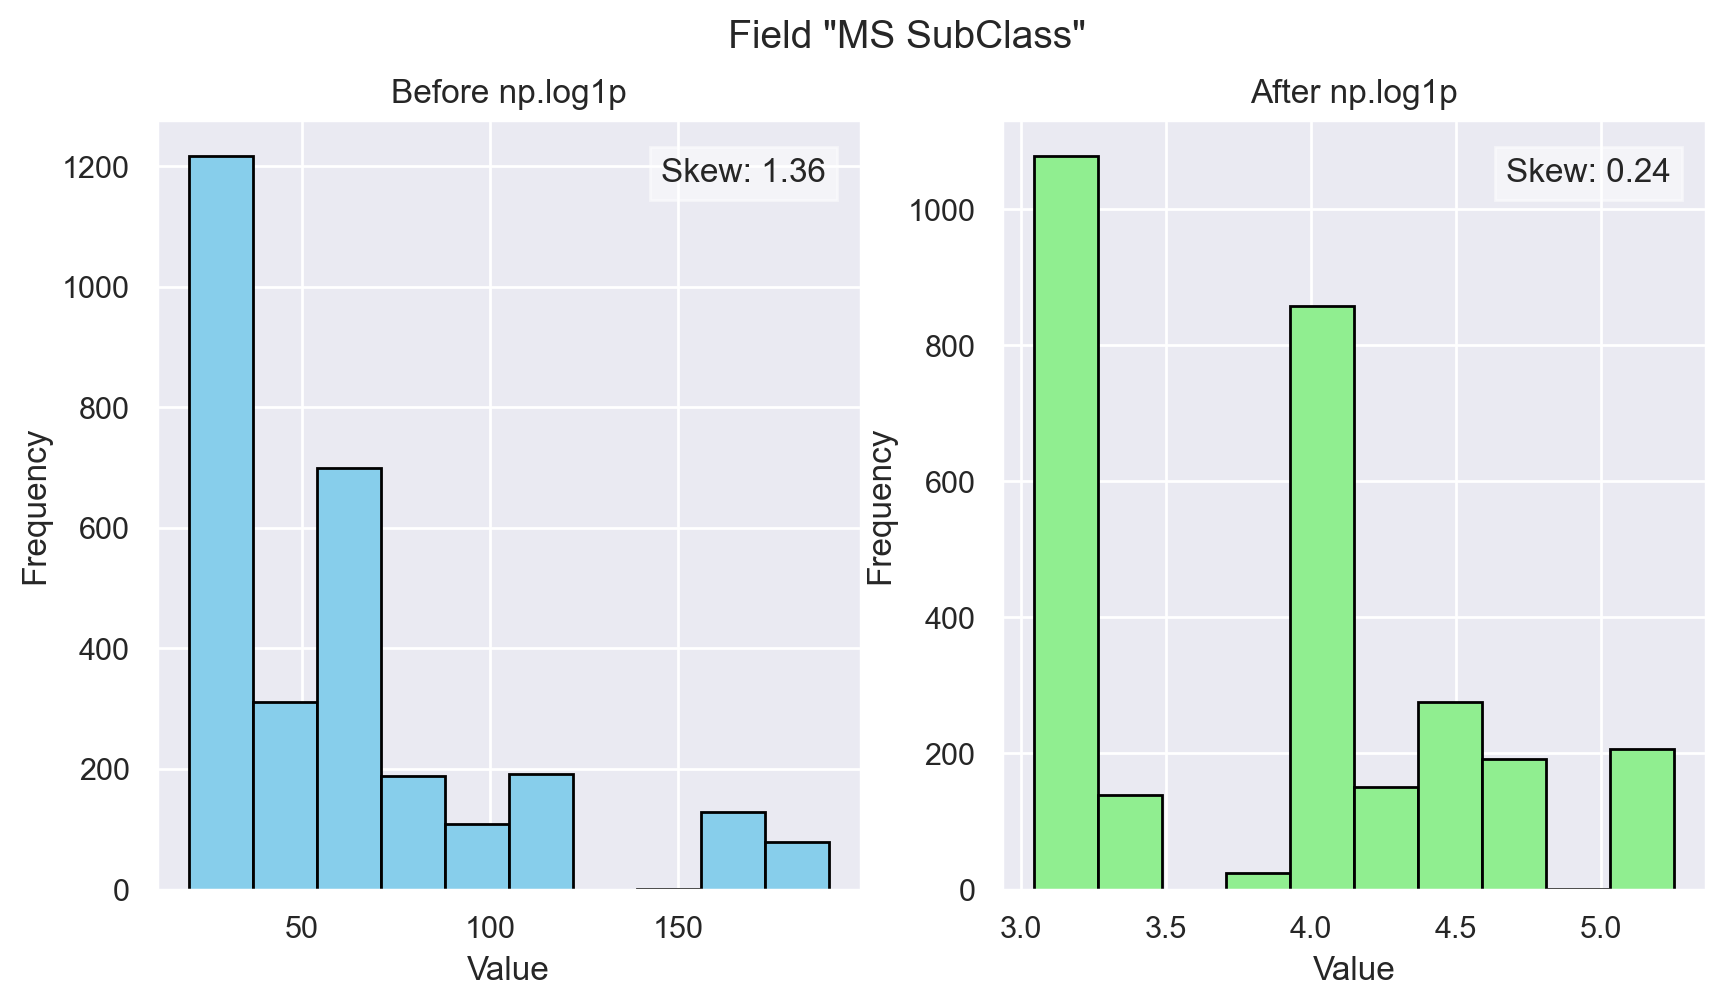

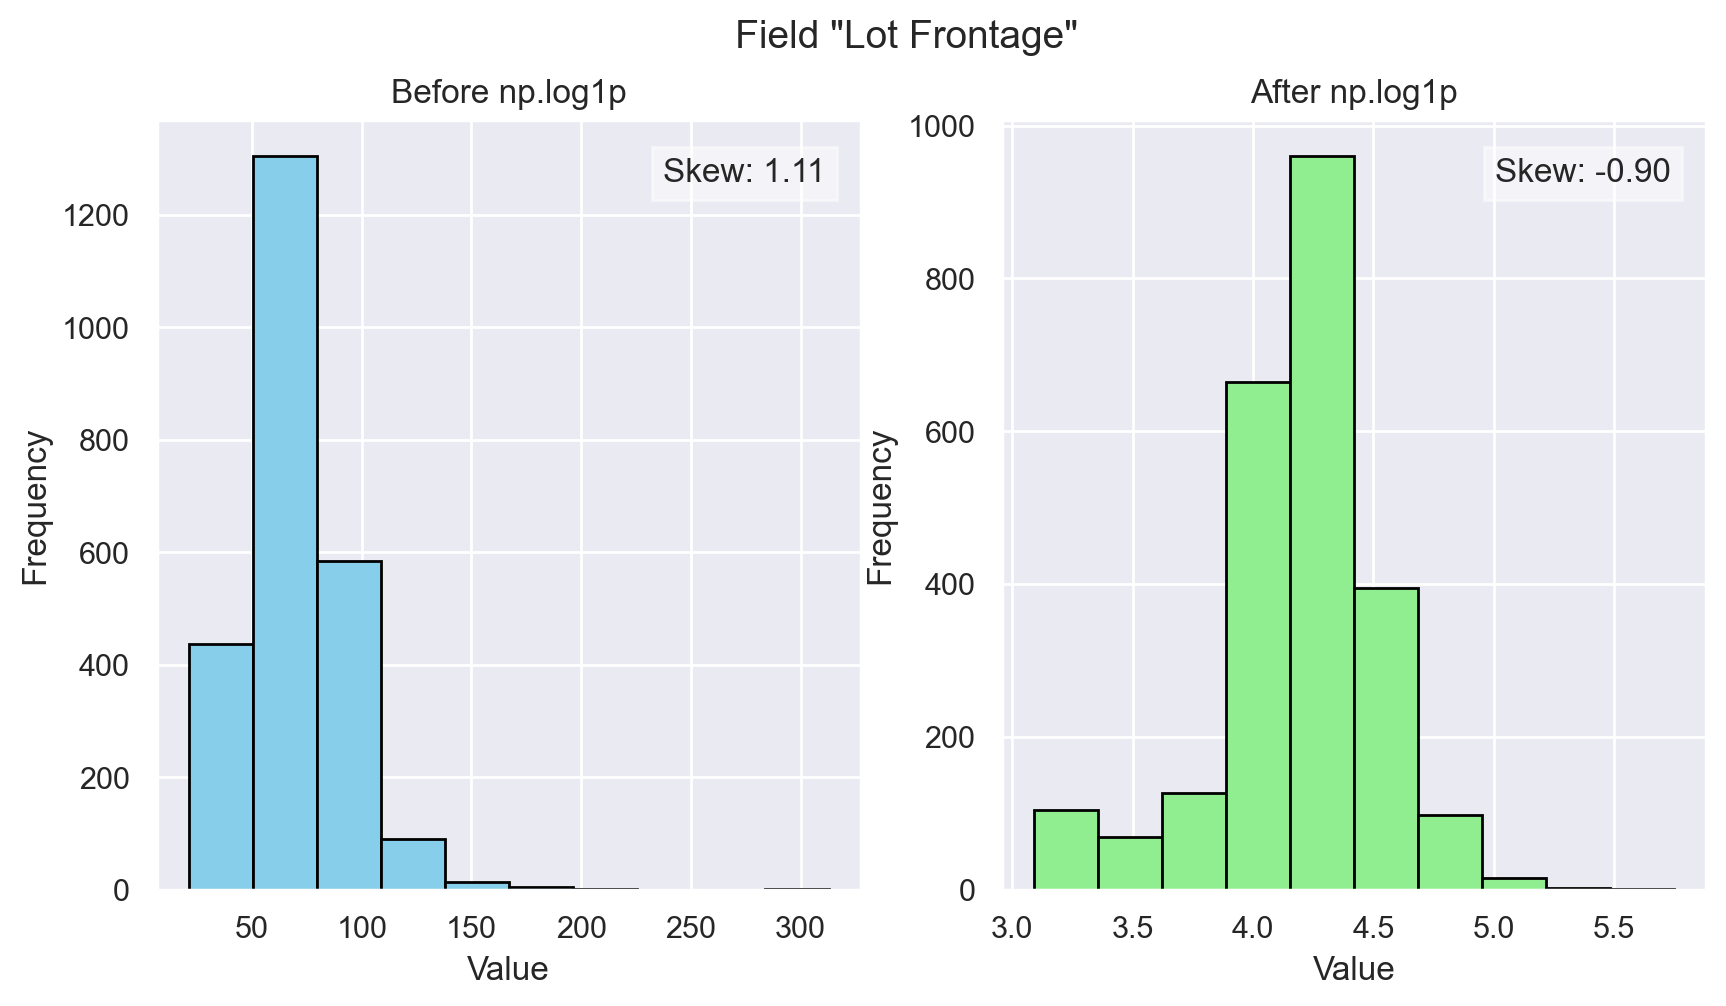

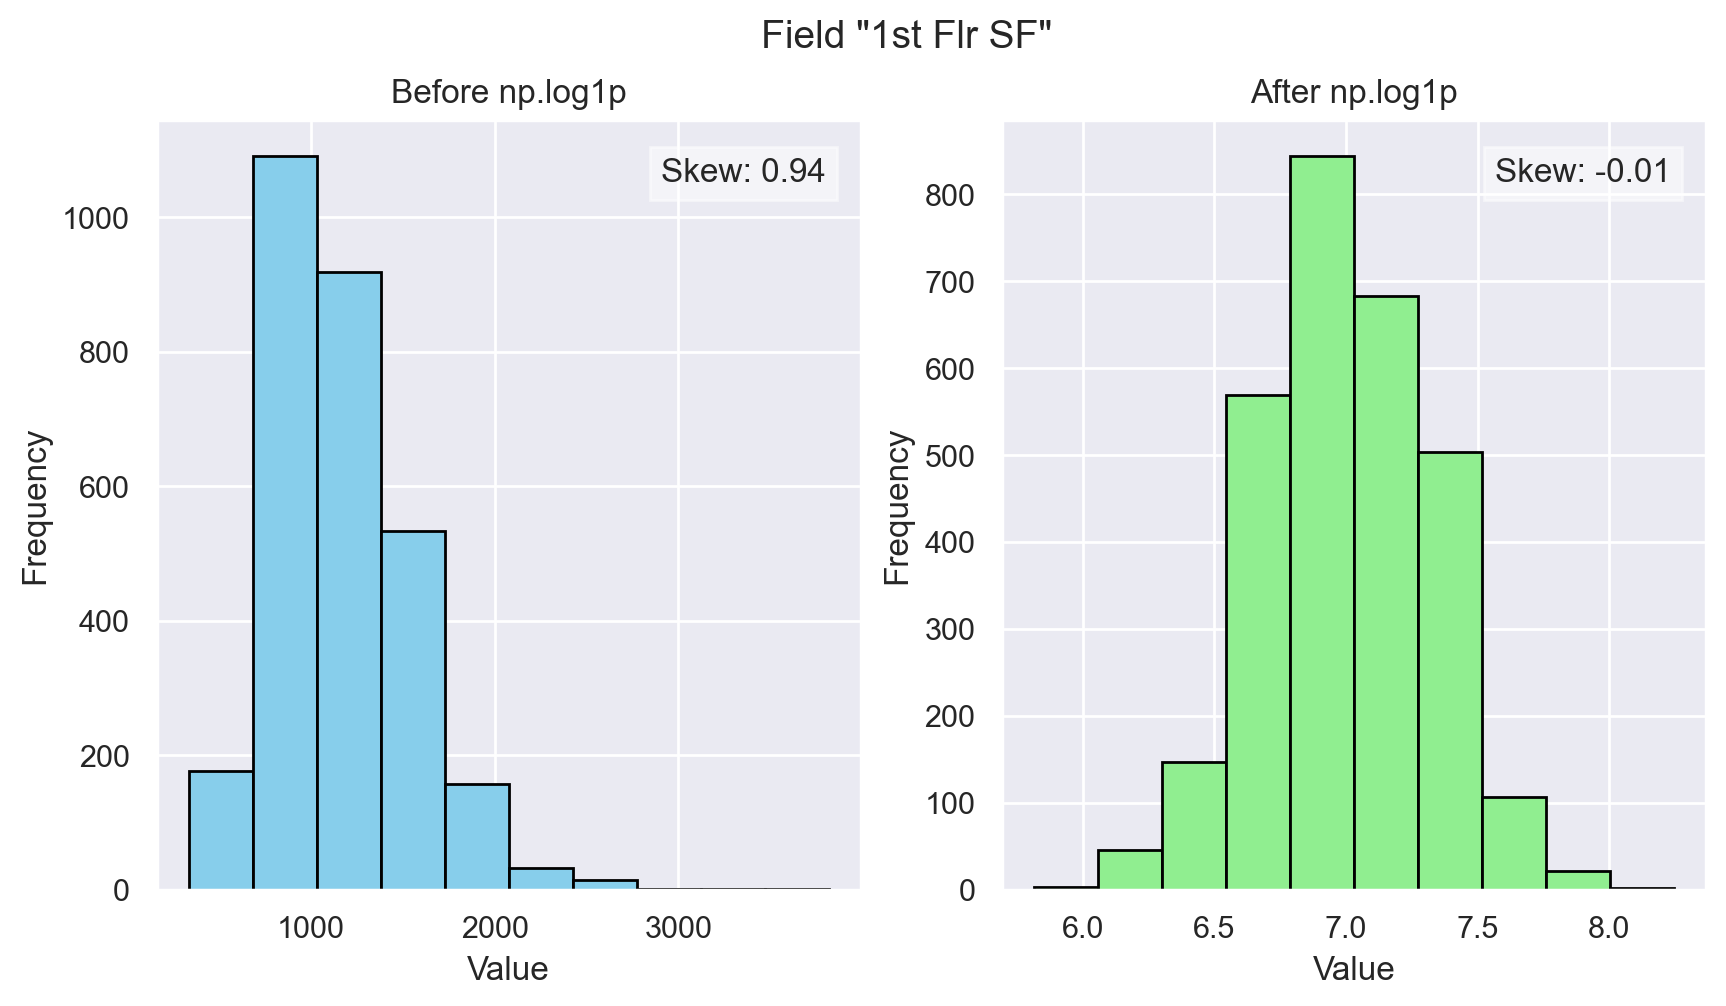

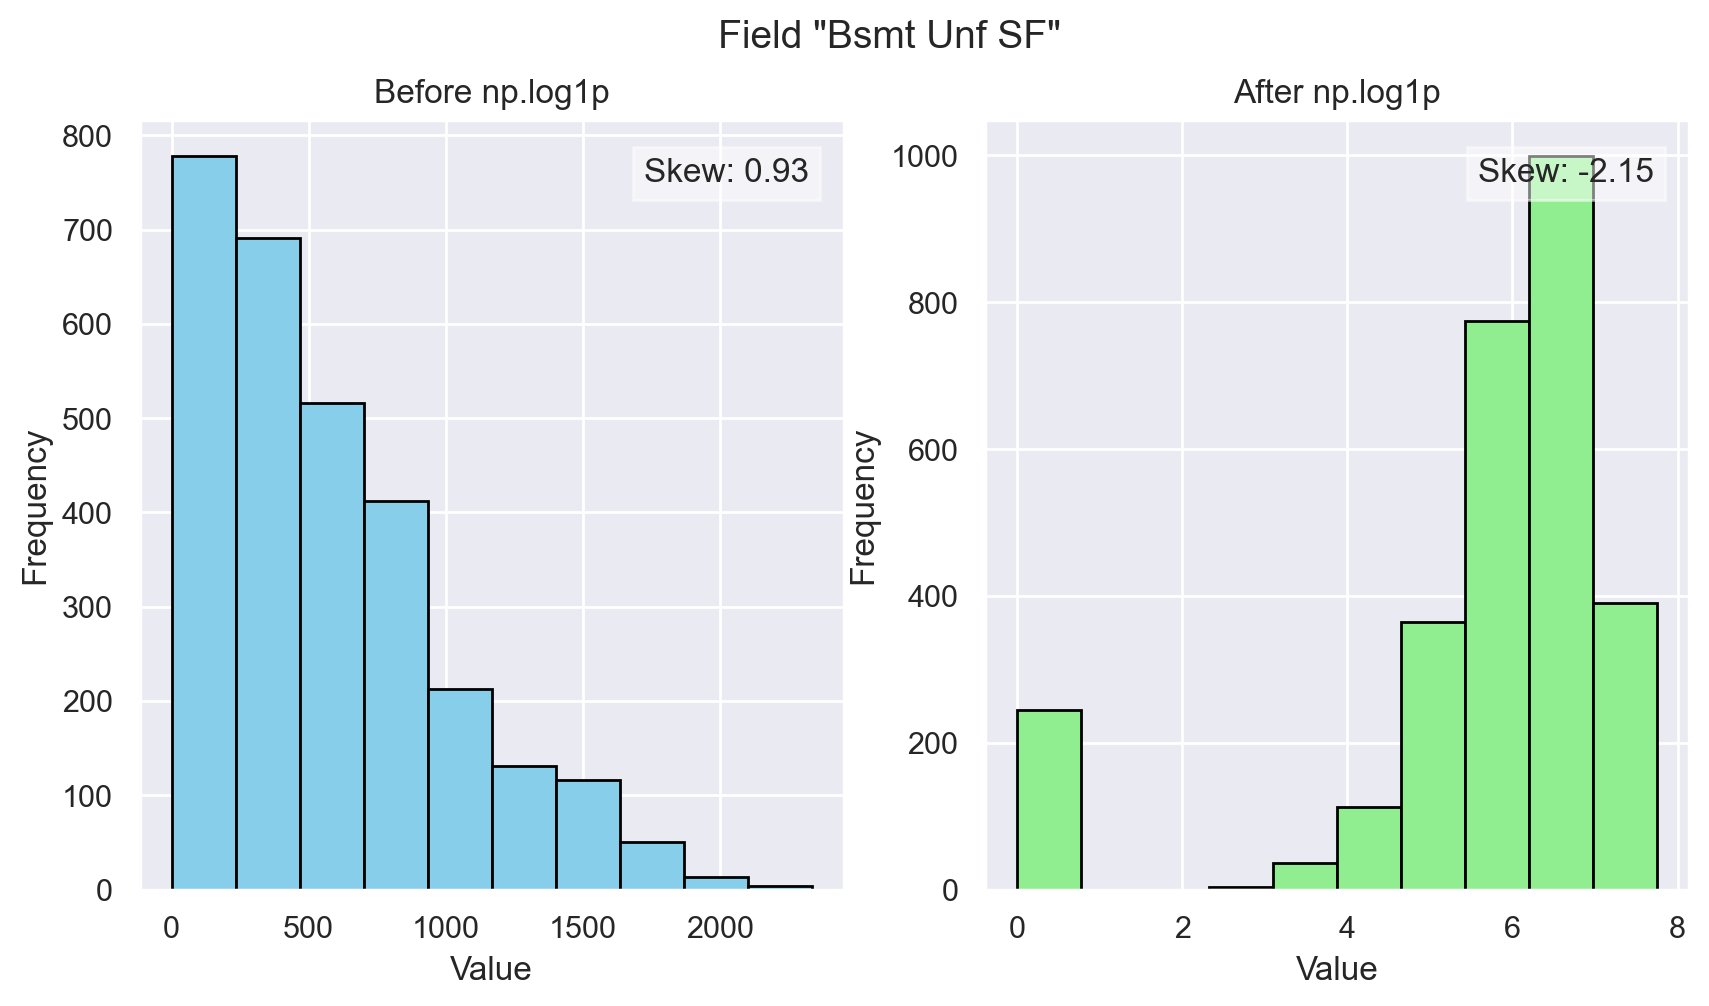

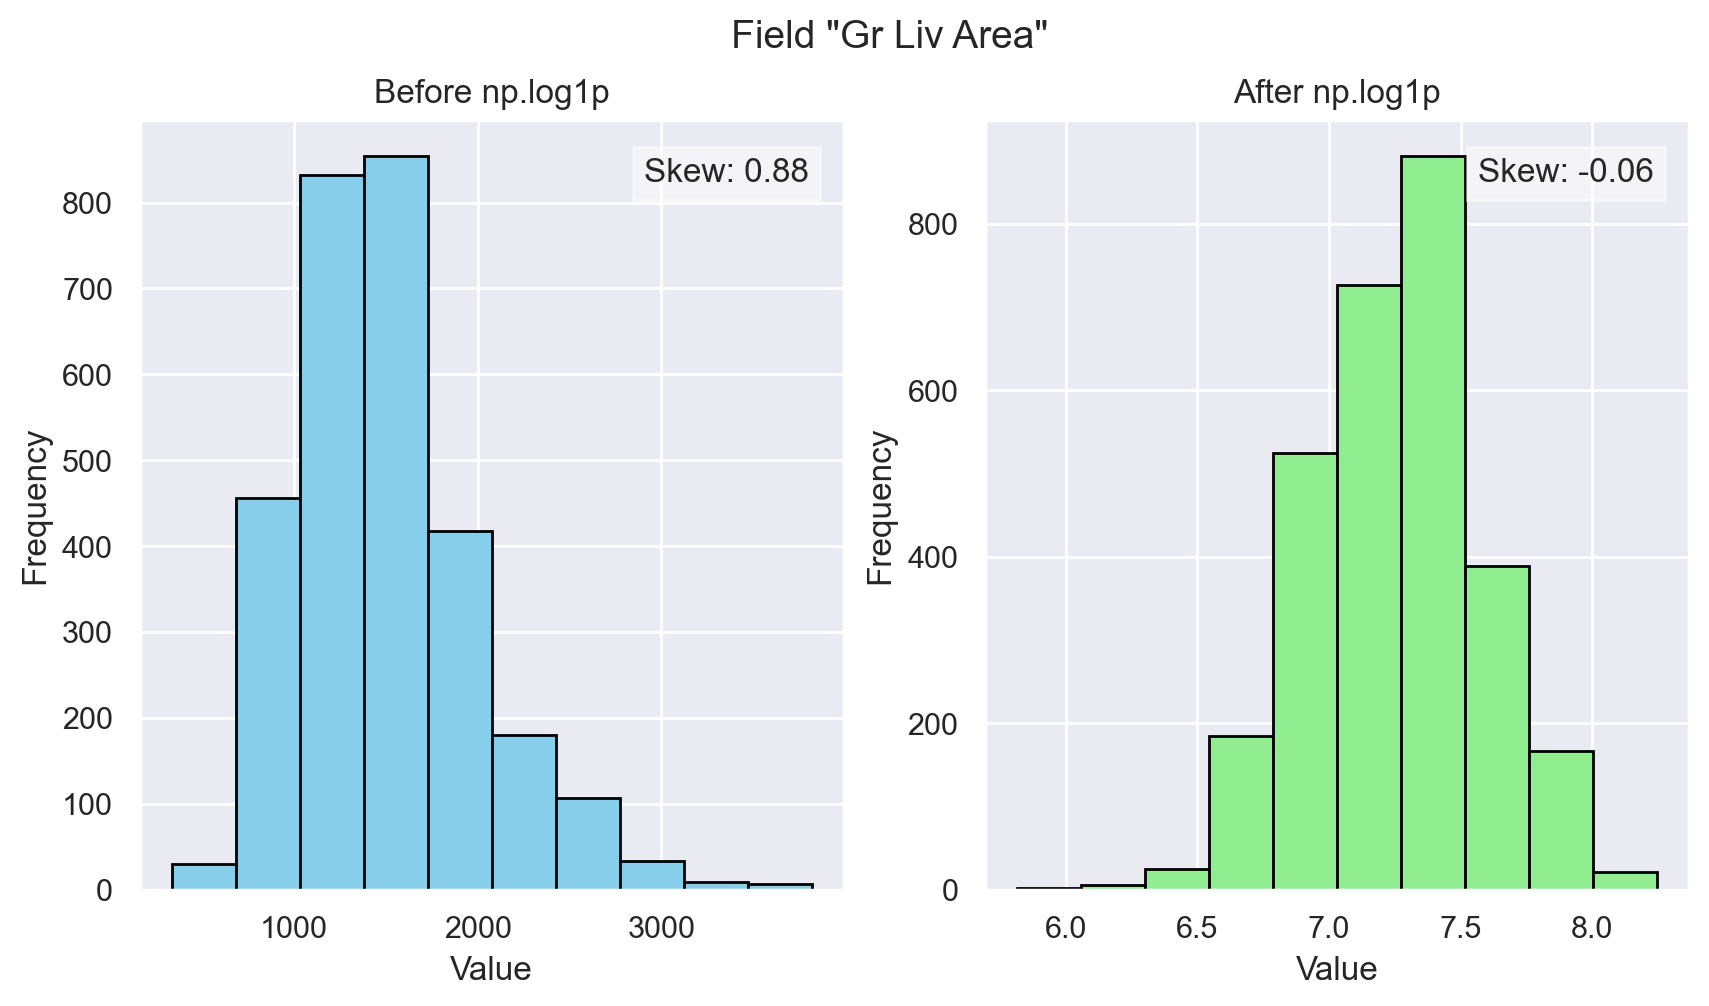

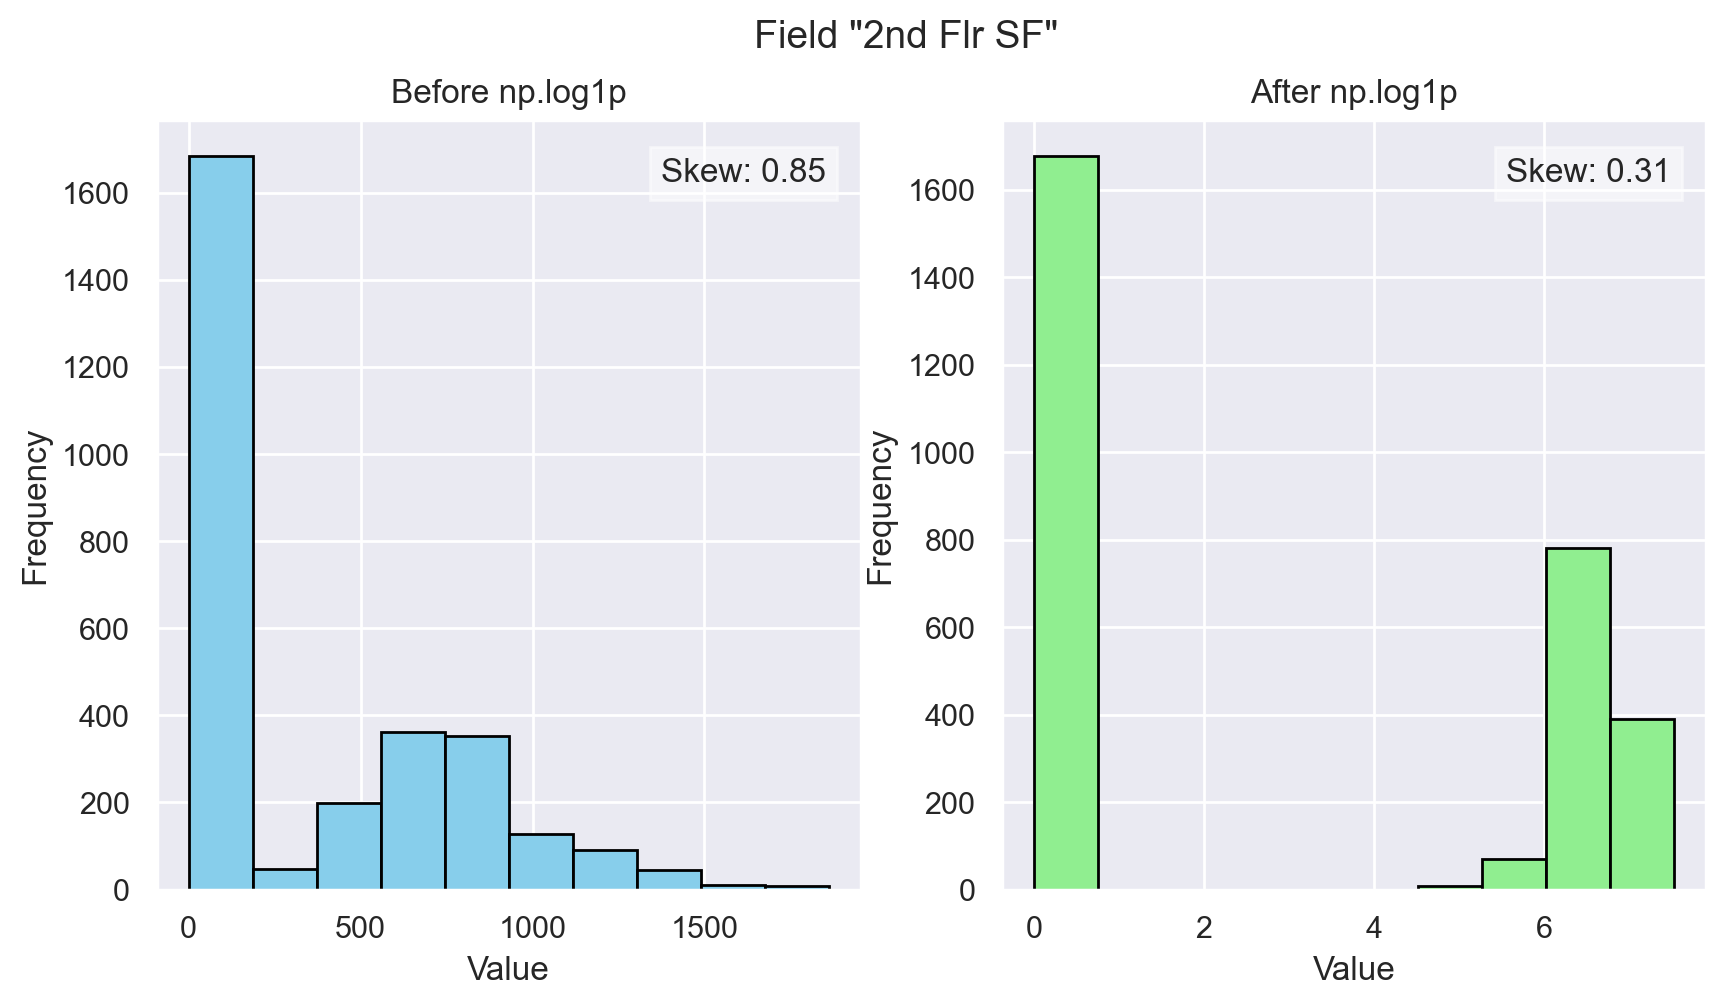

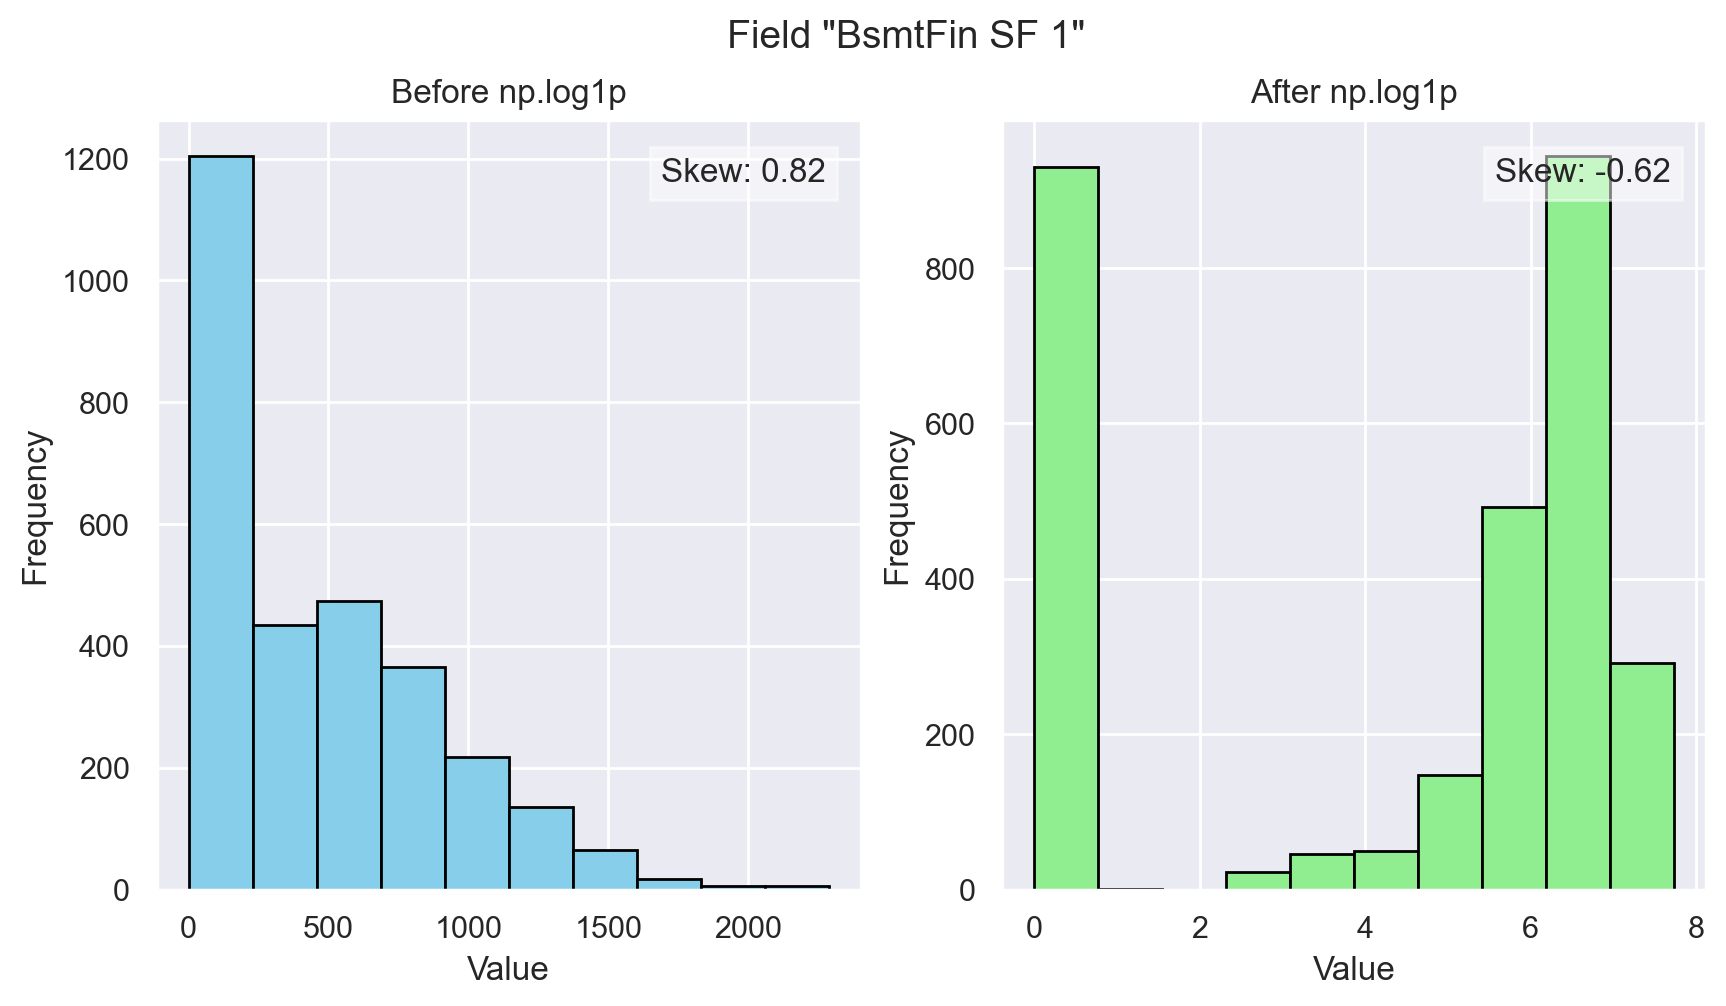

In [99]:
# Recorremos cada columna identificada como sesgada
for col in skew_cols.index:
    # Generamos la gráfica para cada columna
    plot_log_transform_with_skew(df, col)


In [101]:
# Realizamos la transformación logarítmica en las columnas con alta asimetría (skew)

for col in skew_cols.index.values:       # Recorremos cada columna identificada como sesgada
    if col == "SalePrice":               # Excluimos 'SalePrice' porque suele tratarse por separado
        continue
    df[col] = df[col].apply(np.log1p)    # Aplicamos np.log1p (log(1+x)) para reducir la asimetría

In [103]:
# We now have a larger set of potentially-useful features
df.shape

(2925, 80)

In [105]:
# There are a *lot* of variables. Let's go back to our saved original data and look at how many values are missing for each variable. 
df = data
data.isnull().sum().sort_values()

Order                0
Sale Condition       0
Heating QC           0
Central Air          0
1st Flr SF           0
                  ... 
Mas Vnr Type      1774
Fence             2354
Alley             2727
Misc Feature      2820
Pool QC           2914
Length: 82, dtype: int64

In [135]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

Seleccionemos sólo algunas columnas numéricas para ilustrar las transformaciones de características básicas.

In [108]:
smaller_df= df.loc[:,['Lot Area', 'Overall Qual', 'Overall Cond', 
                      'Year Built', 'Year Remod/Add', 'Gr Liv Area', 
                      'Full Bath', 'Bedroom AbvGr', 'Fireplaces', 
                      'Garage Cars','SalePrice']]

In [110]:
# Now we can look at summary statistics of the subset data
smaller_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Lot Area,2925.0,10103.583590,7781.999124,1300.0,7438.0,9428.0,11515.0,215245.0
Overall Qual,2925.0,6.088205,1.402953,1.0,5.0,6.0,7.0,10.0
Overall Cond,2925.0,5.563761,1.112262,1.0,5.0,5.0,6.0,9.0
Year Built,2925.0,1971.302906,30.242474,1872.0,1954.0,1973.0,2001.0,2010.0
Year Remod/Add,2925.0,1984.234188,20.861774,1950.0,1965.0,1993.0,2004.0,2010.0
Gr Liv Area,2925.0,1493.978803,486.273646,334.0,1126.0,1441.0,1740.0,3820.0
Full Bath,2925.0,1.564786,0.551386,0.0,1.0,2.0,2.0,4.0
Bedroom AbvGr,2925.0,2.853675,0.827737,0.0,2.0,3.0,3.0,8.0
Fireplaces,2925.0,0.596923,0.645349,0.0,0.0,1.0,1.0,4.0
Garage Cars,2924.0,1.765048,0.759834,0.0,1.0,2.0,2.0,5.0


In [112]:
smaller_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2925 entries, 0 to 2929
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Lot Area        2925 non-null   int64  
 1   Overall Qual    2925 non-null   int64  
 2   Overall Cond    2925 non-null   int64  
 3   Year Built      2925 non-null   int64  
 4   Year Remod/Add  2925 non-null   int64  
 5   Gr Liv Area     2925 non-null   int64  
 6   Full Bath       2925 non-null   int64  
 7   Bedroom AbvGr   2925 non-null   int64  
 8   Fireplaces      2925 non-null   int64  
 9   Garage Cars     2924 non-null   float64
 10  SalePrice       2925 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 274.2 KB


In [114]:
# There appears to be one NA in Garage Cars - we will take a simple approach and fill it with 0
smaller_df = smaller_df.fillna(0)

In [116]:
smaller_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2925 entries, 0 to 2929
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Lot Area        2925 non-null   int64  
 1   Overall Qual    2925 non-null   int64  
 2   Overall Cond    2925 non-null   int64  
 3   Year Built      2925 non-null   int64  
 4   Year Remod/Add  2925 non-null   int64  
 5   Gr Liv Area     2925 non-null   int64  
 6   Full Bath       2925 non-null   int64  
 7   Bedroom AbvGr   2925 non-null   int64  
 8   Fireplaces      2925 non-null   int64  
 9   Garage Cars     2925 non-null   float64
 10  SalePrice       2925 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 274.2 KB


## Pair plot of features
Ahora que tenemos un buen conjunto de datos filtrado, generemos elementos visuales para comprender mejor las relaciones entre el objetivo y la característica-objetivo: ¡pairplot es ideal para esto!

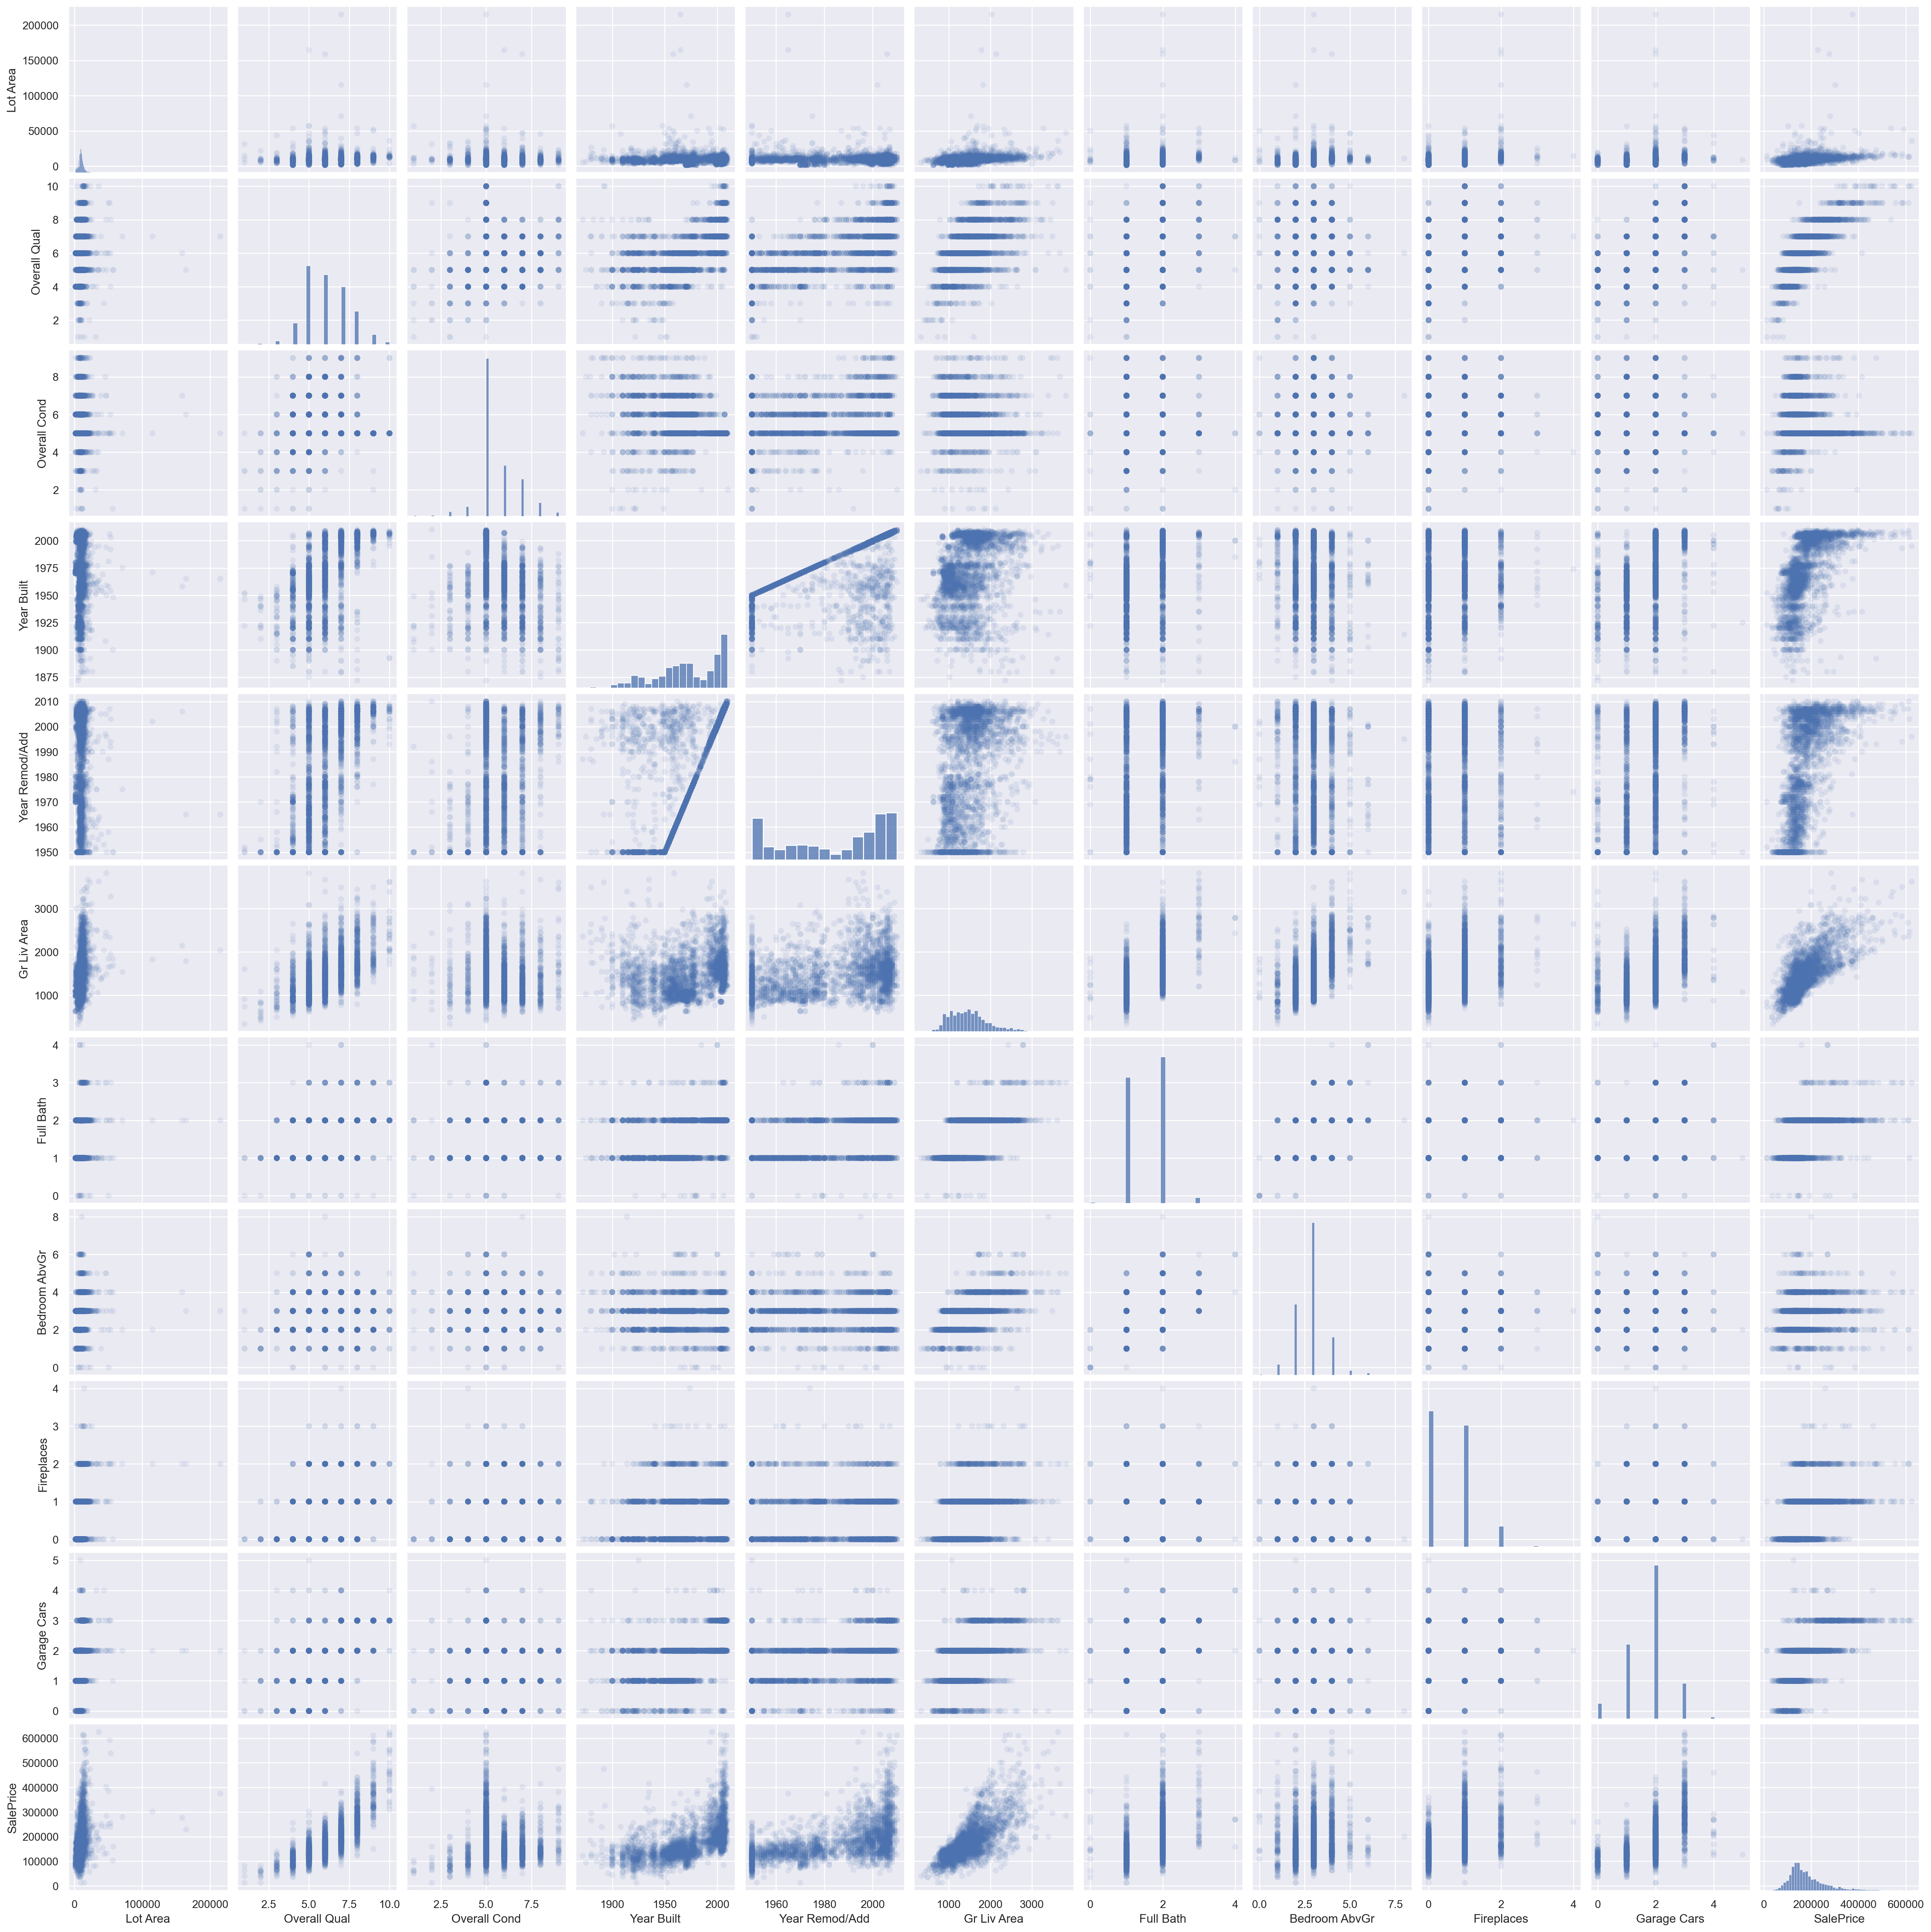

In [120]:
sns.pairplot(smaller_df, plot_kws=dict(alpha=.1, edgecolor='none'))

### Discusión sobre exploración de datos :

1. ¿Qué nos dicen estos gráficos sobre la distribución del objetivo?

2. ¿Qué nos dicen estos gráficos sobre la relación entre las características y el objetivo? ¿Crees que la regresión lineal es adecuada para este problema? ¿Se te ocurre alguna transformación de características?

3- ¿Qué nos dicen estos gráficos sobre la relación entre varios pares de características? ¿Crees que podría haber algún problema?

Queremos asegurarnos de que no haya demasiada **multicolinealidad** entre cada una de nuestras características ya que eso puede desechar nuestra interpretación de algo como la regresión lineal.

#### Suppose our target variable is the SalePrice. We can set up separate variables for features and target.

In [125]:
#Separate our features from our target

X = smaller_df.loc[:,['Lot Area', 'Overall Qual', 'Overall Cond', 
                      'Year Built', 'Year Remod/Add', 'Gr Liv Area', 
                      'Full Bath', 'Bedroom AbvGr', 'Fireplaces', 
                      'Garage Cars']]

y = smaller_df['SalePrice']

In [127]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2925 entries, 0 to 2929
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Lot Area        2925 non-null   int64  
 1   Overall Qual    2925 non-null   int64  
 2   Overall Cond    2925 non-null   int64  
 3   Year Built      2925 non-null   int64  
 4   Year Remod/Add  2925 non-null   int64  
 5   Gr Liv Area     2925 non-null   int64  
 6   Full Bath       2925 non-null   int64  
 7   Bedroom AbvGr   2925 non-null   int64  
 8   Fireplaces      2925 non-null   int64  
 9   Garage Cars     2925 non-null   float64
dtypes: float64(1), int64(9)
memory usage: 251.4 KB


Ahora que tenemos los datos de características/objetivos X, Y listos para usar, estamos casi listos para ajustar y evaluar un modelo de referencia utilizando nuestro conjunto de características actual. Necesitaremos crear una **división de entrenamiento/validación** antes de ajustar y puntuar el modelo.

Dado que dividiremos repetidamente X, y en las mismas particiones train/val y ajustaremos/puntuaremos nuevos modelos a medida que actualizamos nuestro conjunto de características, definiremos una función reutilizable que complete todos estos pasos, haciendo que nuestro código/proceso sea más eficiente en el futuro.

Genial, sigamos adelante y ejecutemos esta función en nuestro conjunto de características de referencia y tomémonos un tiempo para analizar los resultados.

In [130]:
smaller_df.columns

Index(['Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Gr Liv Area', 'Full Bath', 'Bedroom AbvGr',
       'Fireplaces', 'Garage Cars', 'SalePrice'],
      dtype='object')

## Ingeniería de características básicas: adición de términos polinomiales y de interacción 

Una de las primeras cosas que buscamos en el diagrama de pares fue evidencia sobre la relación entre cada característica y el objetivo. En ciertas características, como 'Overall Qual' y 'Gr Liv Area' , observamos una relación de curva ascendente en lugar de una simple correspondencia lineal. **Esto sugiere que deberíamos añadir términos polinómicos cuadráticos o transformaciones para dichas características**, lo que nos permite expresar esa relación no lineal mientras seguimos utilizando la regresión lineal como modelo.

Afortunadamente, Pandas facilita la incorporación rápida de esos términos cuadrados como características adicionales a nuestro conjunto de características original. Lo haremos y evaluaremos nuestro modelo de nuevo a continuación.

A medida que vayamos ampliando nuestro conjunto básico de funciones, crearemos una copia del último punto de referencia para poder seguir almacenando nuestros conjuntos de funciones más antiguos.

In [137]:
X2 = X.copy()

X2['OQ2'] = X2['Overall Qual'] ** 2
X2['GLA2'] = X2['Gr Liv Area'] ** 2


Actualmente, cada característica se considera una cantidad independiente. Sin embargo, pueden existir **efectos de interacción** , en los que el impacto de una característica puede depender del valor actual de otra.

Por ejemplo, podría haber una prima más alta por aumentar la "Calidad General" en viviendas construidas más recientemente. Si existe dicha prima o un efecto similar, una función que multiplique la "Calidad General" por el "Año de Construcción" puede ayudarnos a capturarla.

Otro estilo de término de interacción involucra proporciones de características: por ejemplo, para obtener algo como calidad por pie cuadrado, podríamos dividir 'Calidad general' por 'Área del lote' .

Intentemos agregar ambos términos de interacción y veamos cómo impactan en los resultados del modelo.

In [140]:
X3 = X2.copy()

# multiplicative interaction
X3['OQ_x_YB'] = X3['Overall Qual'] * X3['Year Built']

# division interaction
X3['OQ_/_LA'] = X3['Overall Qual'] / X3['Lot Area']



-----
**Interaction Feature Exercise**: What other interactions do you think might be helpful? Why? 

-----

## Categorías y características derivadas de agregados de categorías 
Incorporar **características categóricas** en modelos de regresión lineal es bastante sencillo: podemos crear una nueva columna de características para cada valor de categoría y rellenarlas con unos y ceros para indicar qué categoría está presente en cada fila. Este método se denomina **variables ficticias** o **codificación one-hot** .

Primero exploraremos esto usando la función "House Style" del marco de datos original. Antes de pasar directamente a las variables ficticias, conviene comprobar el número de categorías para asegurarse de que todas tengan una representación adecuada.

In [144]:
data['House Style'].value_counts()

House Style
1Story    1480
2Story     869
1.5Fin     314
SLvl       128
SFoyer      83
2.5Unf      24
1.5Unf      19
2.5Fin       8
Name: count, dtype: int64

Esto se ve bien, y aquí hay un vistazo rápido de cómo aparecen realmente las características ficticias:

In [147]:
pd.get_dummies(df['House Style'], drop_first=True).head()

,1.5Unf,1Story,2.5Fin,2.5Unf,2Story,SFoyer,SLvl
0,False,True,False,False,False,False,False
1,False,True,False,False,False,False,False
2,False,True,False,False,False,False,False
3,False,True,False,False,False,False,False
4,False,False,False,False,True,False,False


Podemos acceder a `pd.get_dummies()` todo nuestro conjunto de datos para obtener rápidamente datos con todas las características originales y la representación de variables ficticias de cualquier característica categórica. Analicemos algunos valores de variables.

In [150]:
# Contar cuántas veces aparece cada vecindario en la columna 'Neighborhood' del DataFrame 'df'
# y almacenar los resultados en 'nbh_counts'. Luego, mostrar el conteo de cada vecindario.
nbh_counts = df.Neighborhood.value_counts()
nbh_counts


Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    191
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
SawyerW    125
Mitchel    114
BrkSide    108
Crawfor    103
IDOTRR      93
Timber      72
NoRidge     69
StoneBr     51
SWISU       48
ClearCr     44
MeadowV     37
BrDale      30
Blmngtn     28
Veenker     24
NPkVill     23
Blueste     10
Greens       8
GrnHill      2
Landmrk      1
Name: count, dtype: int64

For this category, let's map the few least-represented neighborhoods to an "other" category before adding the feature to our feature set and running a new benchmark.

Para esta categoría, asigne los pocos Neighborhood menos representados a una categoría "other" antes de agregar la característica a nuestro conjunto de características y ejecutar una nueva prueba comparativa.

In [161]:
nbh_counts[nbh_counts <= 8]

Neighborhood
Greens     8
GrnHill    2
Landmrk    1
Name: count, dtype: int64

In [153]:
other_nbhs = list(nbh_counts[nbh_counts <= 8].index) #Se obtiene en lista
other_nbhs

['Greens', 'GrnHill', 'Landmrk']

In [163]:
X4 = X3.copy()

X4['Neighborhood'] = df['Neighborhood'].replace(other_nbhs, 'Other')


In [165]:
nbh_counts = X4.Neighborhood.value_counts()
nbh_counts

Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    191
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
SawyerW    125
Mitchel    114
BrkSide    108
Crawfor    103
IDOTRR      93
Timber      72
NoRidge     69
StoneBr     51
SWISU       48
ClearCr     44
MeadowV     37
BrDale      30
Blmngtn     28
Veenker     24
NPkVill     23
Other       11
Blueste     10
Name: count, dtype: int64

### Llegando a funciones más sofisticadas 
Concluyamos nuestra introducción a la ingeniería de características considerando un tipo de característica más compleja que puede ser muy útil para ciertos problemas. No parece aportar mucho a lo que tenemos hasta ahora, pero es un estilo de ingeniería a tener en cuenta para el futuro.

Crearemos características que capturen la posición de un valor de característica en relación con los miembros de la categoría a la que pertenece. En particular, calcularemos la desviación del valor de característica de una fila respecto al valor medio de la categoría a la que pertenece. Esto ayuda a capturar información sobre una característica en relación con la distribución de la categoría; por ejemplo, qué tan bonita es una casa en comparación con otras casas de su vecindario o su estilo.

A continuación definimos código reutilizable para generar características de este formato. ¡Siéntete libre de reutilizarlo para futuros trabajos de ingeniería de características!

In [181]:
def add_deviation_feature(X, feature, category):
    # Esta función agrega una nueva columna a X que representa la desviación
    #estándar de cada valor de 'feature' con respecto a su media dentro de 'category'.

    # Crear un objeto groupby temporal agrupando X por la columna 'category'
    # y seleccionando la columna 'feature'.
    category_gb = X.groupby(category)[feature]
    
    # Calcular la media de 'feature' para cada grupo de 'category'
    # y expandirla para que coincida con el índice de X
    category_mean = category_gb.transform(lambda x: x.mean())
    
    # Calcular la desviación estándar de 'feature' para cada grupo de 'category'
    # y expandirla para que coincida con el índice de X
    category_std = category_gb.transform(lambda x: x.std())
    
    # Calcular la desviación estandarizada de cada valor de 'feature' respecto
    # a la media de su grupo: (valor - media del grupo) / desviación estándar del grupo
    deviation_feature = (X[feature] - category_mean) / category_std 
    
    # Agregar la nueva columna a X con un nombre que indique
    # que es la desviación de 'feature' respecto a 'category'
    X[feature + '_Dev_' + category] = deviation_feature



Sea $X$ un DataFrame de pandas, $feature$ una columna numérica y $category$ una columna categórica.  
La función agrega una nueva columna que mide la **desviación estandarizada** de cada valor respecto a su grupo de categoría.

1. Se calcula la media de cada grupo:
$$
\mu_g = \text{mean}(\{ x_i \in feature \mid i \in g \})
$$

2. Se calcula la desviación estándar de cada grupo:
$$
\sigma_g = \text{std}(\{ x_i \in feature \mid i \in g \})
$$

3. Se calcula la desviación estandarizada de cada observación $x_i$ en su grupo $g(i)$:
$$
x_i^{\text{dev}} = \frac{x_i - \mu_{g(i)}}{\sigma_{g(i)}}
$$

4. Se agrega como nueva columna al DataFrame:
$$
feature\_Dev\_category = x_i^{\text{dev}}
$$

De esta manera, cada valor se expresa en **unidades de desviación estándar respecto a su categoría**, permitiendo comparar valores dentro de distintos gru

%%latex

Supongamos que tenemos el siguiente DataFrame:

$$
\begin{array}{c|c}
\text{Category} & \text{Value} \\
\hline
A & 10 \\
A & 12 \\
A & 14 \\
B & 20 \\
B & 22 \\
B & 24 \\
\end{array}
$$

Queremos calcular la desviación estandarizada de \text{Value} respecto a cada \text{Category}.

1. Para la categoría A:

$$
\mu_A = \frac{10 + 12 + 14}{3} = 12, \quad
\sigma_A = \sqrt{\frac{(10-12)^2 + (12-12)^2 + (14-12)^2}{3}} \approx 2
$$

2. Para la categoría B:

$$
\mu_B = \frac{20 + 22 + 24}{3} = 22, \quad
\sigma_B = \sqrt{\frac{(20-22)^2 + (22-22)^2 + (24-22)^2}{3}} \approx 2
$$

3. Calculamos la desviación estandarizada para cada valor $x_i$ en su grupo $g(i)$:

$$
x_i^{\text{dev}} = \frac{x_i - \mu_{g(i)}}{\sigma_{g(i)}}
$$

4. Resultados finales:

$$
\begin{array}{c|c|c}
\text{Category} & \text{Value} & \text{Value\_Dev\_Category} \\
\hline
A & 10 & \frac{10-12}{2} = -1.0 \\
A & 12 & \frac{12-12}{2} = 0.0 \\
A & 14 & \frac{14-12}{2} = 1.0 \\
B & 20 & \frac{20-22}{2} = -1.0 \\
B & 22 & \frac{22-22}{2} = 0.0 \\
B & 24 & \frac{24-22}{2} = 1.0 \\
\end{array}
$$

Cada valor ahora se expresa en **unidades de desviación estándar respecto a su categoría**, permitiendo comparaciones relativas dentro de los grupos.
pos de manera relativa.
grupos de forma relativa.


And now let's use our feature generation code to add 2 new deviation features, and run a final benchmark.

In [183]:
X5 = X4.copy()
X5['House Style'] = df['House Style']
add_deviation_feature(X5, 'Year Built', 'House Style')
add_deviation_feature(X5, 'Overall Qual', 'Neighborhood')


In [185]:
X5.head()

,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Gr Liv Area,Full Bath,Bedroom AbvGr,Fireplaces,Garage Cars,OQ2,GLA2,OQ_x_YB,OQ_/_LA,Neighborhood,House Style,Year Built_Dev_House Style,Overall Qual_Dev_Neighborhood
0,31770,6,5,1960,1960,1656,1,3,2,2.0,36,2742336,11760,0.000189,NAmes,1Story,-0.590334,0.857503
1,11622,5,6,1961,1961,896,1,2,0,1.0,25,802816,9805,0.000430,NAmes,1Story,-0.551186,-0.430205
2,14267,6,6,1958,1958,1329,1,3,0,1.0,36,1766241,11748,0.000421,NAmes,1Story,-0.668629,0.857503
3,11160,7,5,1968,1968,2110,2,3,2,2.0,49,4452100,13776,0.000627,NAmes,1Story,-0.277154,2.145211
4,13830,5,5,1997,1998,1629,2,3,1,2.0,25,2653641,9985,0.000362,Gilbert,2Story,0.545208,-2.101974


## Polynomial Features in Scikit-Learn

`sklearn` allows you to build many higher-order terms at once with `PolynomialFeatures`

In [187]:
from sklearn.preprocessing import PolynomialFeatures

In [189]:
# Creamos un objeto PolynomialFeatures de scikit-learn
# Esto permitirá generar nuevas características polinomiales a partir de las originales
# degree=2 indica que incluiremos:
#   - el intercepto (término constante)
#   - los términos de grado 1 (las variables originales)
#   - los términos de grado 2 (cuadrados de cada variable y productos cruzados entre variables)
pf = PolynomialFeatures(degree=2)


In [191]:
features = ['Lot Area', 'Overall Qual']
pf.fit(df[features])

PolynomialFeatures()

In [207]:
# 3. Instanciamos PolynomialFeatures (grado 2)
# -----------------------------------------------
pf = PolynomialFeatures(degree=2)

# --------------------------------------------------
# 4. Ajustamos el transformador solo a las columnas seleccionadas
# --------------------------------------------------
pf.fit(df[features])

# --------------------------------------------------
# 5. Transformamos los datos para crear nuevas características
# --------------------------------------------------
feat_array = pf.transform(df[features])

# --------------------------------------------------
# 6. Creamos DataFrame final con nombres correctos
# --------------------------------------------------
df_poly = pd.DataFrame(feat_array, columns=pf.get_feature_names_out(features))


In [209]:
df_poly

,1,Lot Area,Overall Qual,Lot Area^2,Lot Area Overall Qual,Overall Qual^2
0,1.0,31770.0,6.0,1.009333e+09,190620.0,36.0
1,1.0,11622.0,5.0,1.350709e+08,58110.0,25.0
2,1.0,14267.0,6.0,2.035473e+08,85602.0,36.0
3,1.0,11160.0,7.0,1.245456e+08,78120.0,49.0
4,1.0,13830.0,5.0,1.912689e+08,69150.0,25.0
...,...,...,...,...,...,...
2920,1.0,7937.0,6.0,6.299597e+07,47622.0,36.0
2921,1.0,8885.0,5.0,7.894322e+07,44425.0,25.0
2922,1.0,10441.0,5.0,1.090145e+08,52205.0,25.0
2923,1.0,10010.0,5.0,1.002001e+08,50050.0,25.0


# Resumen 
Si bien aún no hemos recurrido a la predicción, estos ejercicios de ingeniería de características sientan las bases. Generalmente, la ingeniería de características suele seguir una especie de principio de Pareto , según el cual gran parte de las ganancias predictivas se pueden lograr añadiendo un conjunto de características intuitivas y sólidas, como transformaciones polinómicas e interacciones. Incorporar directamente información adicional, como variables categóricas, también puede ser muy útil. Más allá de este punto, la ingeniería de características adicional puede proporcionar rendimientos significativos, aunque potencialmente decrecientes. Su validez depende del caso de uso del modelo.